In [1]:
# Project setup
import sys
import os

PROJECT_ROOT = os.path.abspath("..")
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np

from src.data.loaders import PointsDataset
from src.visualization.visualization_utils import create_meshgrid
from src.visualization.feature_space_plots import PlotManager, plot_in_rectangular_coordinates
from src.data.synthetic import generate_uniform_ring_points, generate_uniform_ring_synthetic_dataset, generate_custom_polar_dataset
from src.features.transformations import cartesian_to_polar, polar_to_curvilinear_r2cos2theta

In [3]:
current_dir = Path.cwd()

# Load the dataset
data_path = current_dir.parent / "data" / "raw" / "points.json"
dataset = PointsDataset.from_json(data_path=data_path)

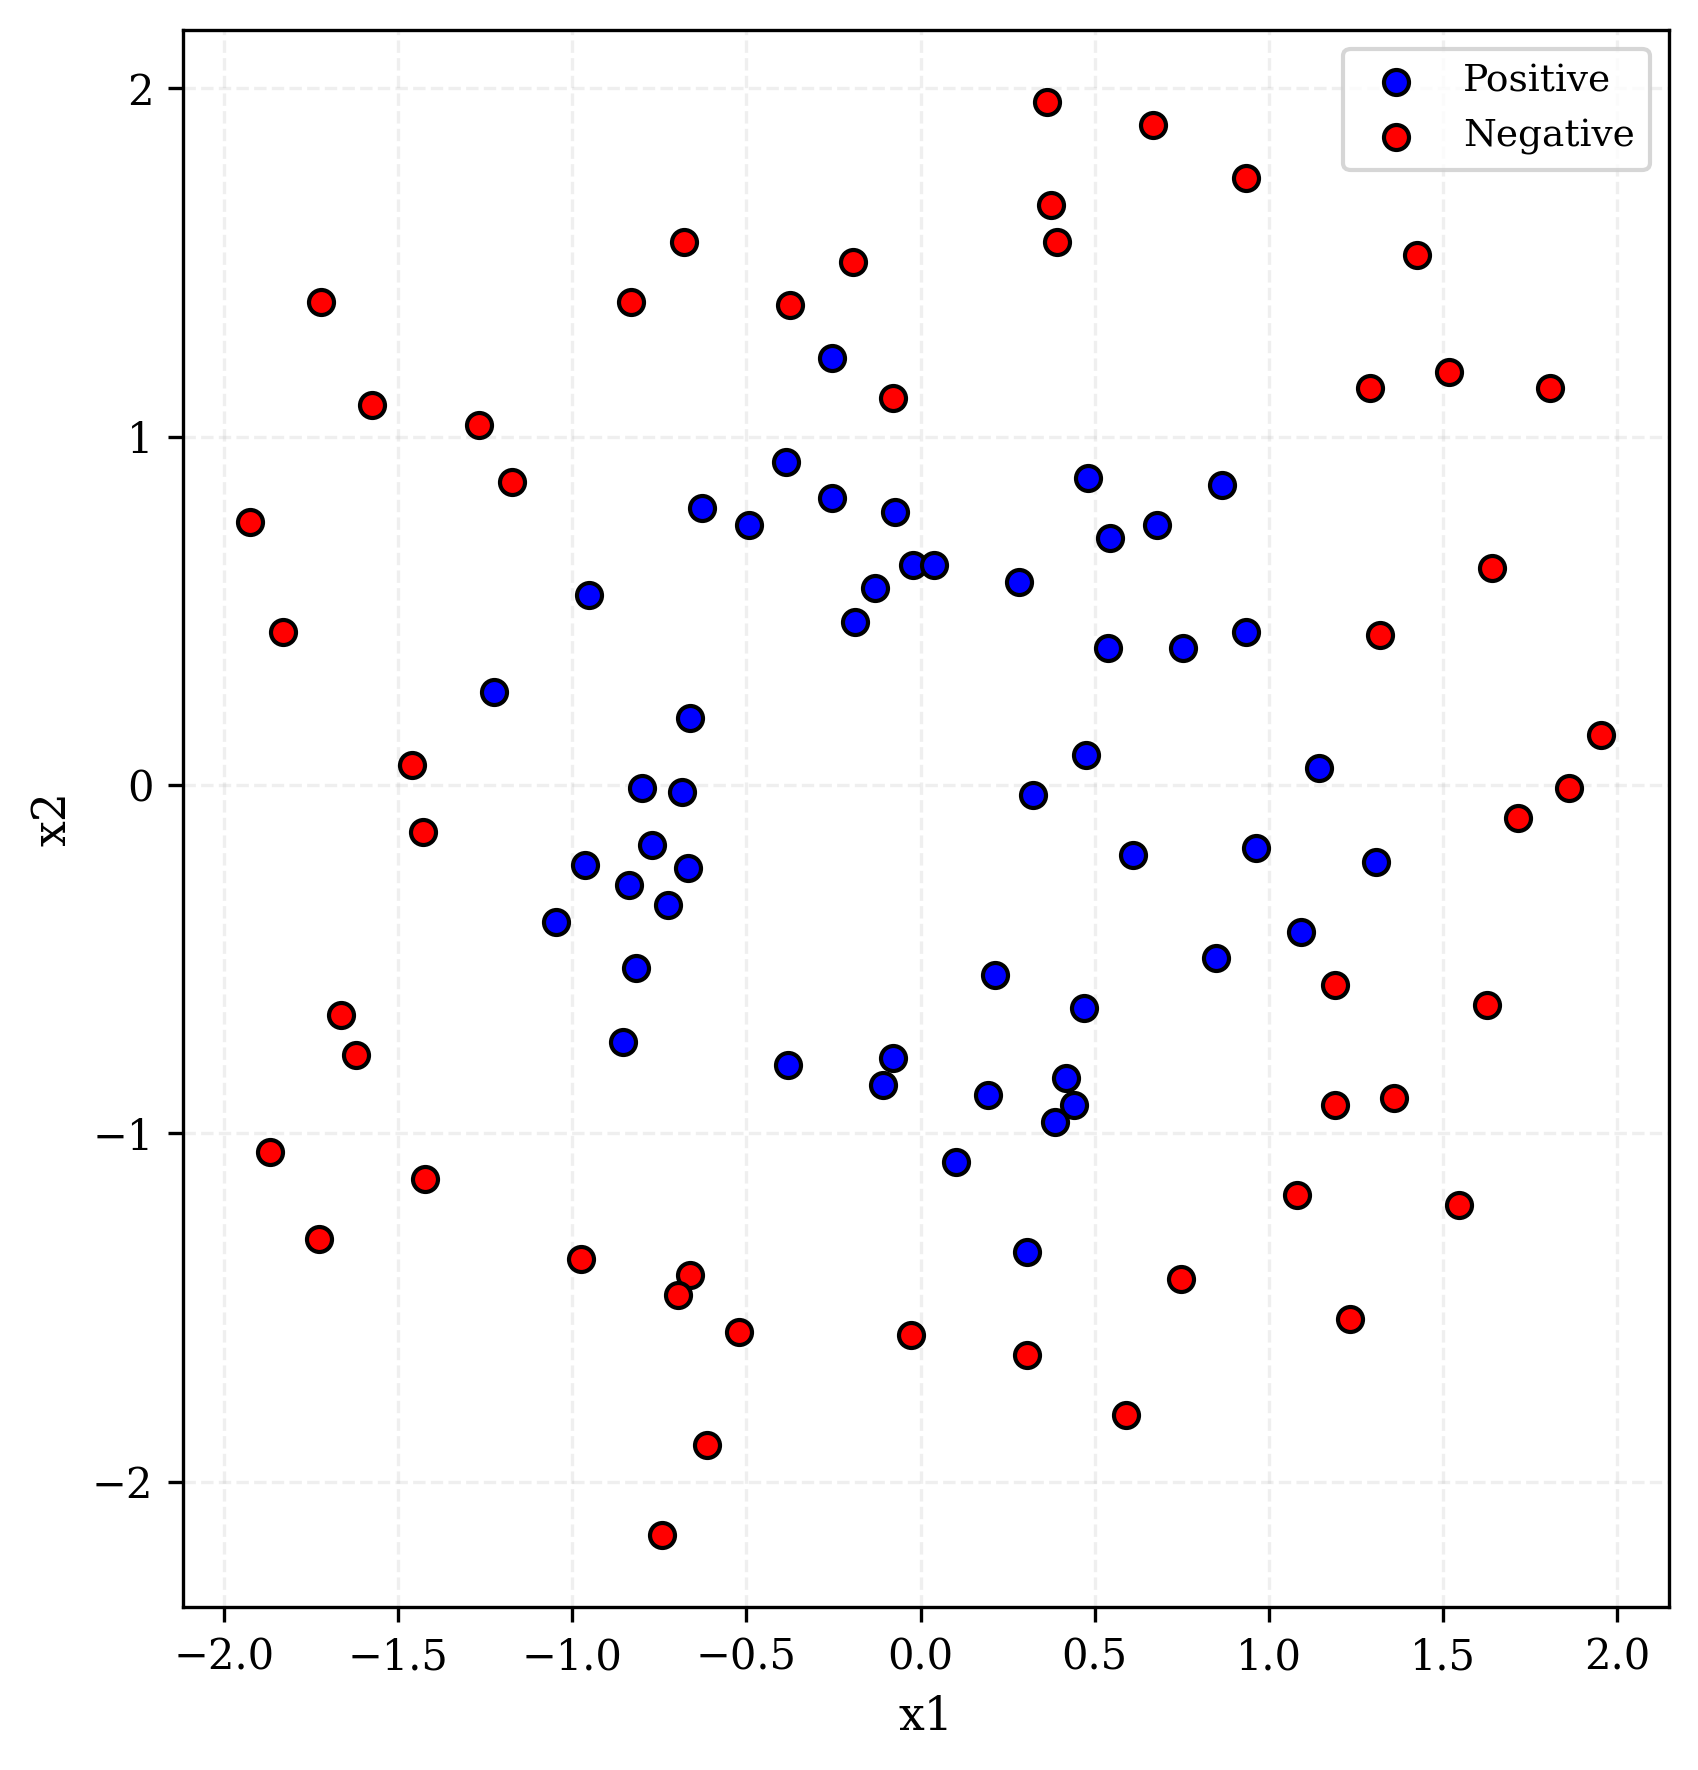

In [4]:
raw_data_fig, raw_data_ax = plot_in_rectangular_coordinates(dataset.X, dataset.y, title='')
raw_data_ax.set_aspect('equal')
display(raw_data_fig)

In [5]:
num_points1 = 100
num_points2 = 80
r_min = 0.0
r_cutoff = 1.0
delta_r_cutoff = 0.0
r_max = 2 * 1.0
overall_noise = 0.1

X1 = pd.DataFrame(
    generate_uniform_ring_points(
        num_points=num_points1, 
        r_min=r_min, r_max=r_cutoff, 
        noise_std=overall_noise,
        coord_system='polar'
        ), columns=['x1', 'x2']
)

X2 = pd.DataFrame(
    generate_uniform_ring_points(
        num_points=num_points2, 
        r_min=r_cutoff+delta_r_cutoff, r_max=r_max,
        noise_std=overall_noise, 
        coord_system='polar'
        ), columns=['x1', 'x2']
)

X = pd.concat([X1, X2])
y = np.concat([np.ones(len(X1)), np.zeros(len(X2))])

X_cart = pd.DataFrame(
    {
        'x1': X['x1'] * np.cos(X['x2']),
        'x2': X['x1'] * np.sin(X['x2'])
    }
)
X_cos2 = polar_to_curvilinear_r2cos2theta(X['x1'], X['x2'])

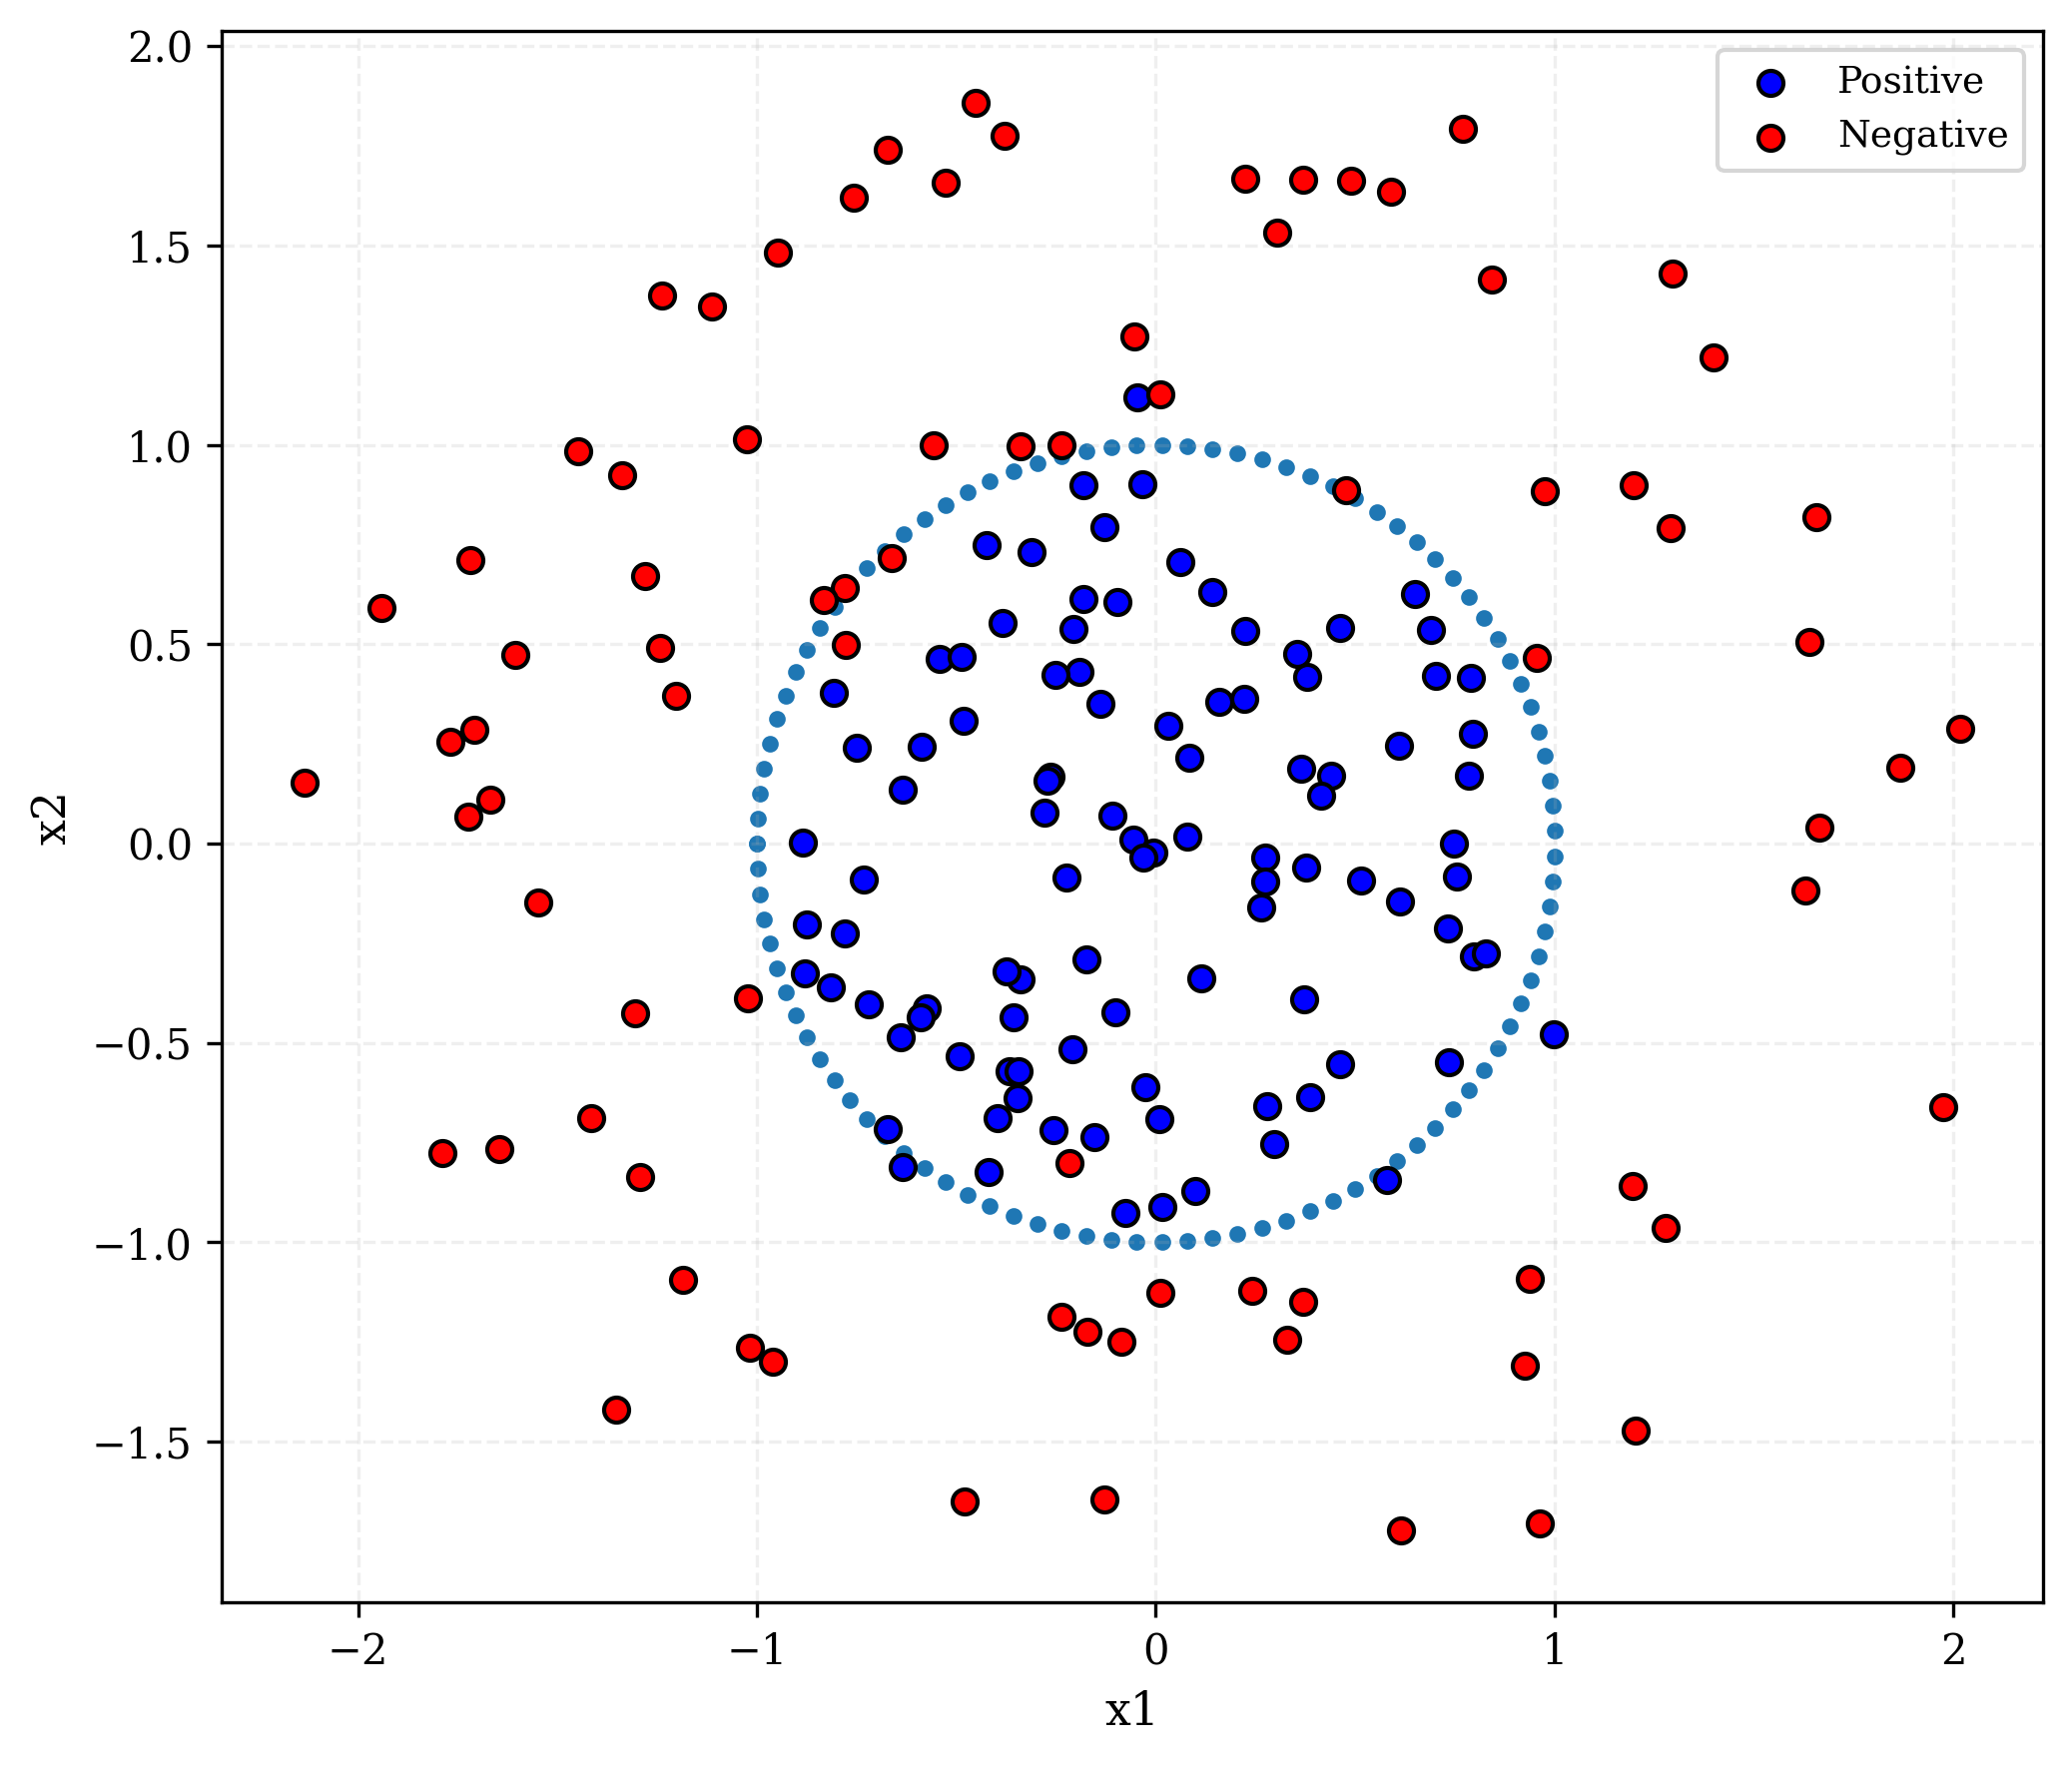

In [6]:
raw_data_fig, raw_data_ax = plot_in_rectangular_coordinates(X=X_cart, y=y, title='', axis_x='x1', axis_y='x2')
R = 1.0
Thetas = np.linspace(-np.pi, np.pi, 100)
raw_data_ax.scatter(R*np.cos(Thetas), R*np.sin(Thetas), marker='.')
raw_data_ax.set_aspect('equal')
display(raw_data_fig)

In [7]:
TP_ref = len(X[(X['x1']<=r_cutoff) & (y==1)])
TN_ref = len(X[(X['x1']>r_cutoff) & (y==0)])

reference_metrics = {
    'accuracy': (TP_ref + TN_ref)/(num_points1+num_points2),
    'precision': TP_ref/(TP_ref + (num_points2-TN_ref)),
    'recall': TP_ref/(num_points1)
}
reference_metrics['f1'] = 2 * (reference_metrics['precision'] * reference_metrics['recall']) / (reference_metrics['precision'] + reference_metrics['recall'])
reference_metrics

{'accuracy': 0.9611111111111111,
 'precision': 0.9696969696969697,
 'recall': 0.96,
 'f1': 0.964824120603015}

In [8]:
# Create a Cartesian meshgrid to plot decision boundaries
grid_x, grid_y, grid_cartesian = create_meshgrid(X_cart, resolution=500)

# Transform meshgrid into polar grid
grid_polar = cartesian_to_polar(grid_x.ravel(), grid_y.ravel())

# Transform polar into curvilinear grid
grid_cos_sqd = pd.DataFrame({ 'x1': grid_polar['x1']**2, 'x2': np.cos(grid_polar['x2'])**2})

,accuracy,precision,recall,f1
0,0.944444,0.916667,0.99,0.951923


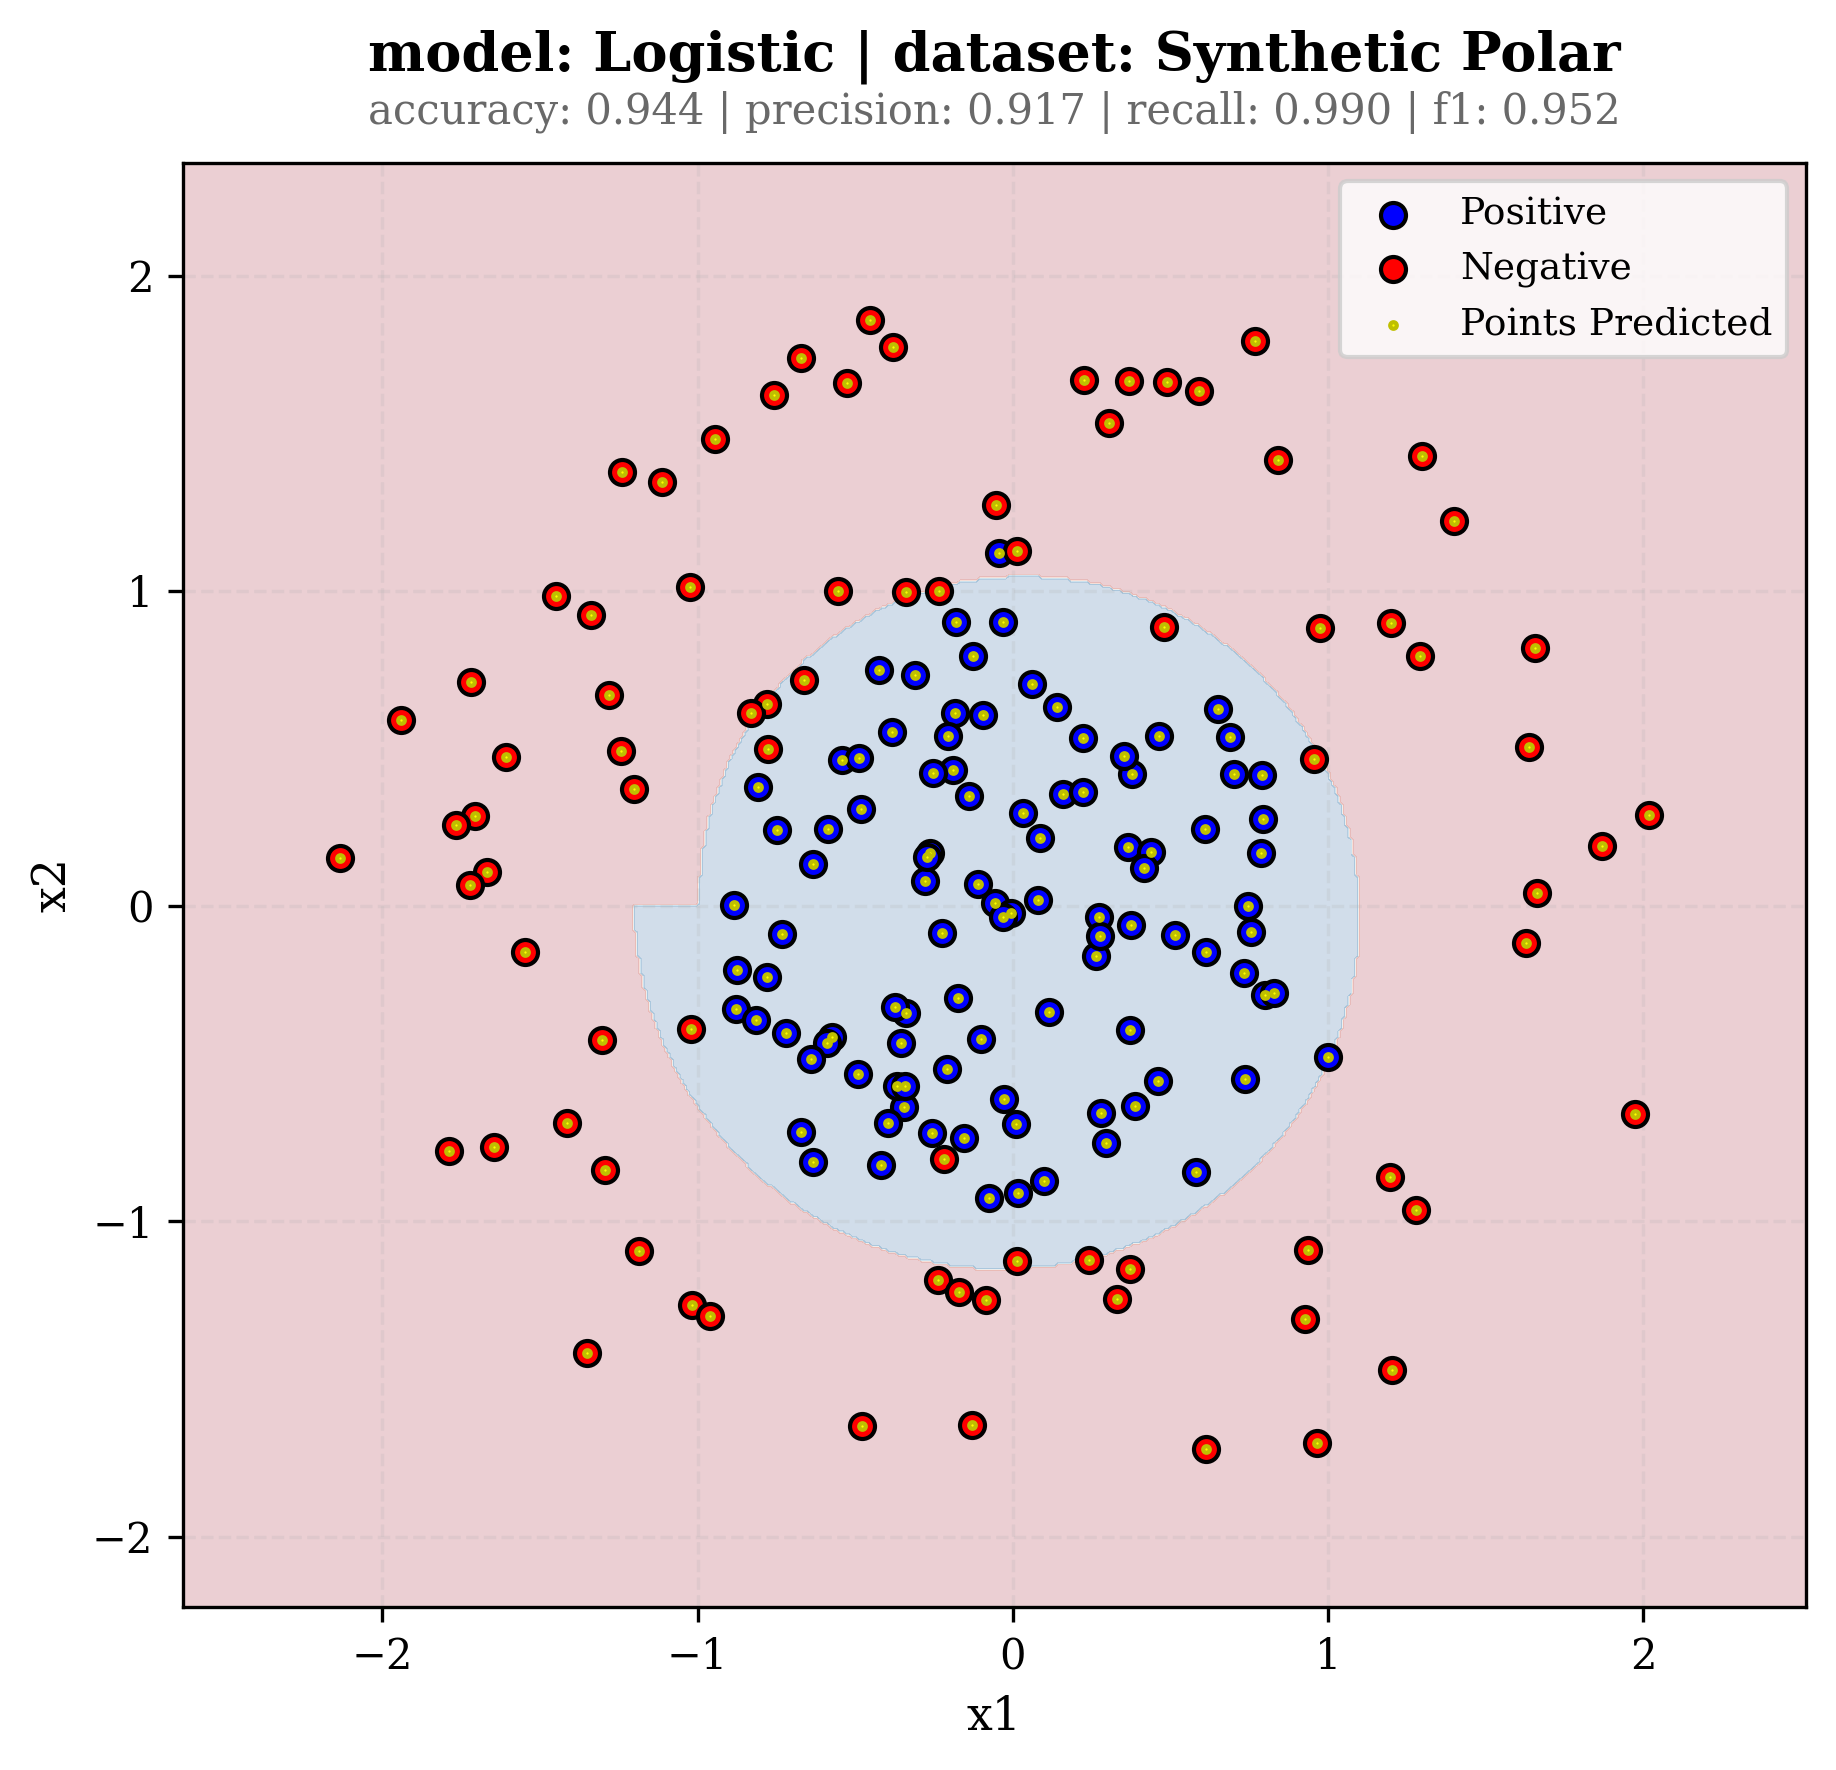

In [9]:
from src.visualization.decision_boundaries import plot_decision_boundary
from sklearn.linear_model import LogisticRegression
from src.evaluation.metrics import ModelMetrics

lr_model = LogisticRegression(random_state=42)
lr_model.fit(X, y)
lr_metrics = ModelMetrics('Logistic Regression', 'Polar', y, lr_model.predict(X))
lr_metrics.compute_metrics()
display(lr_metrics.to_pandas())

lr_fig, lr_ax = plot_decision_boundary(
    model=lr_model, dataset_X=X_cart, dataset_y=y,
    prediction_domain=grid_polar, grid_x=grid_x, grid_y=grid_y,
    title=f'model: Logistic | dataset: Synthetic Polar',
    metrics=lr_metrics.to_dict()
)
lr_ax.set_aspect('equal')
display(lr_fig)

In [10]:
lr_metrics.to_dict()

{'accuracy': 0.9444444444444444,
 'precision': 0.9166666666666666,
 'recall': 0.99,
 'f1': 0.9519230769230769}

,accuracy,precision,recall,f1
0,0.933333,0.907407,0.98,0.942308


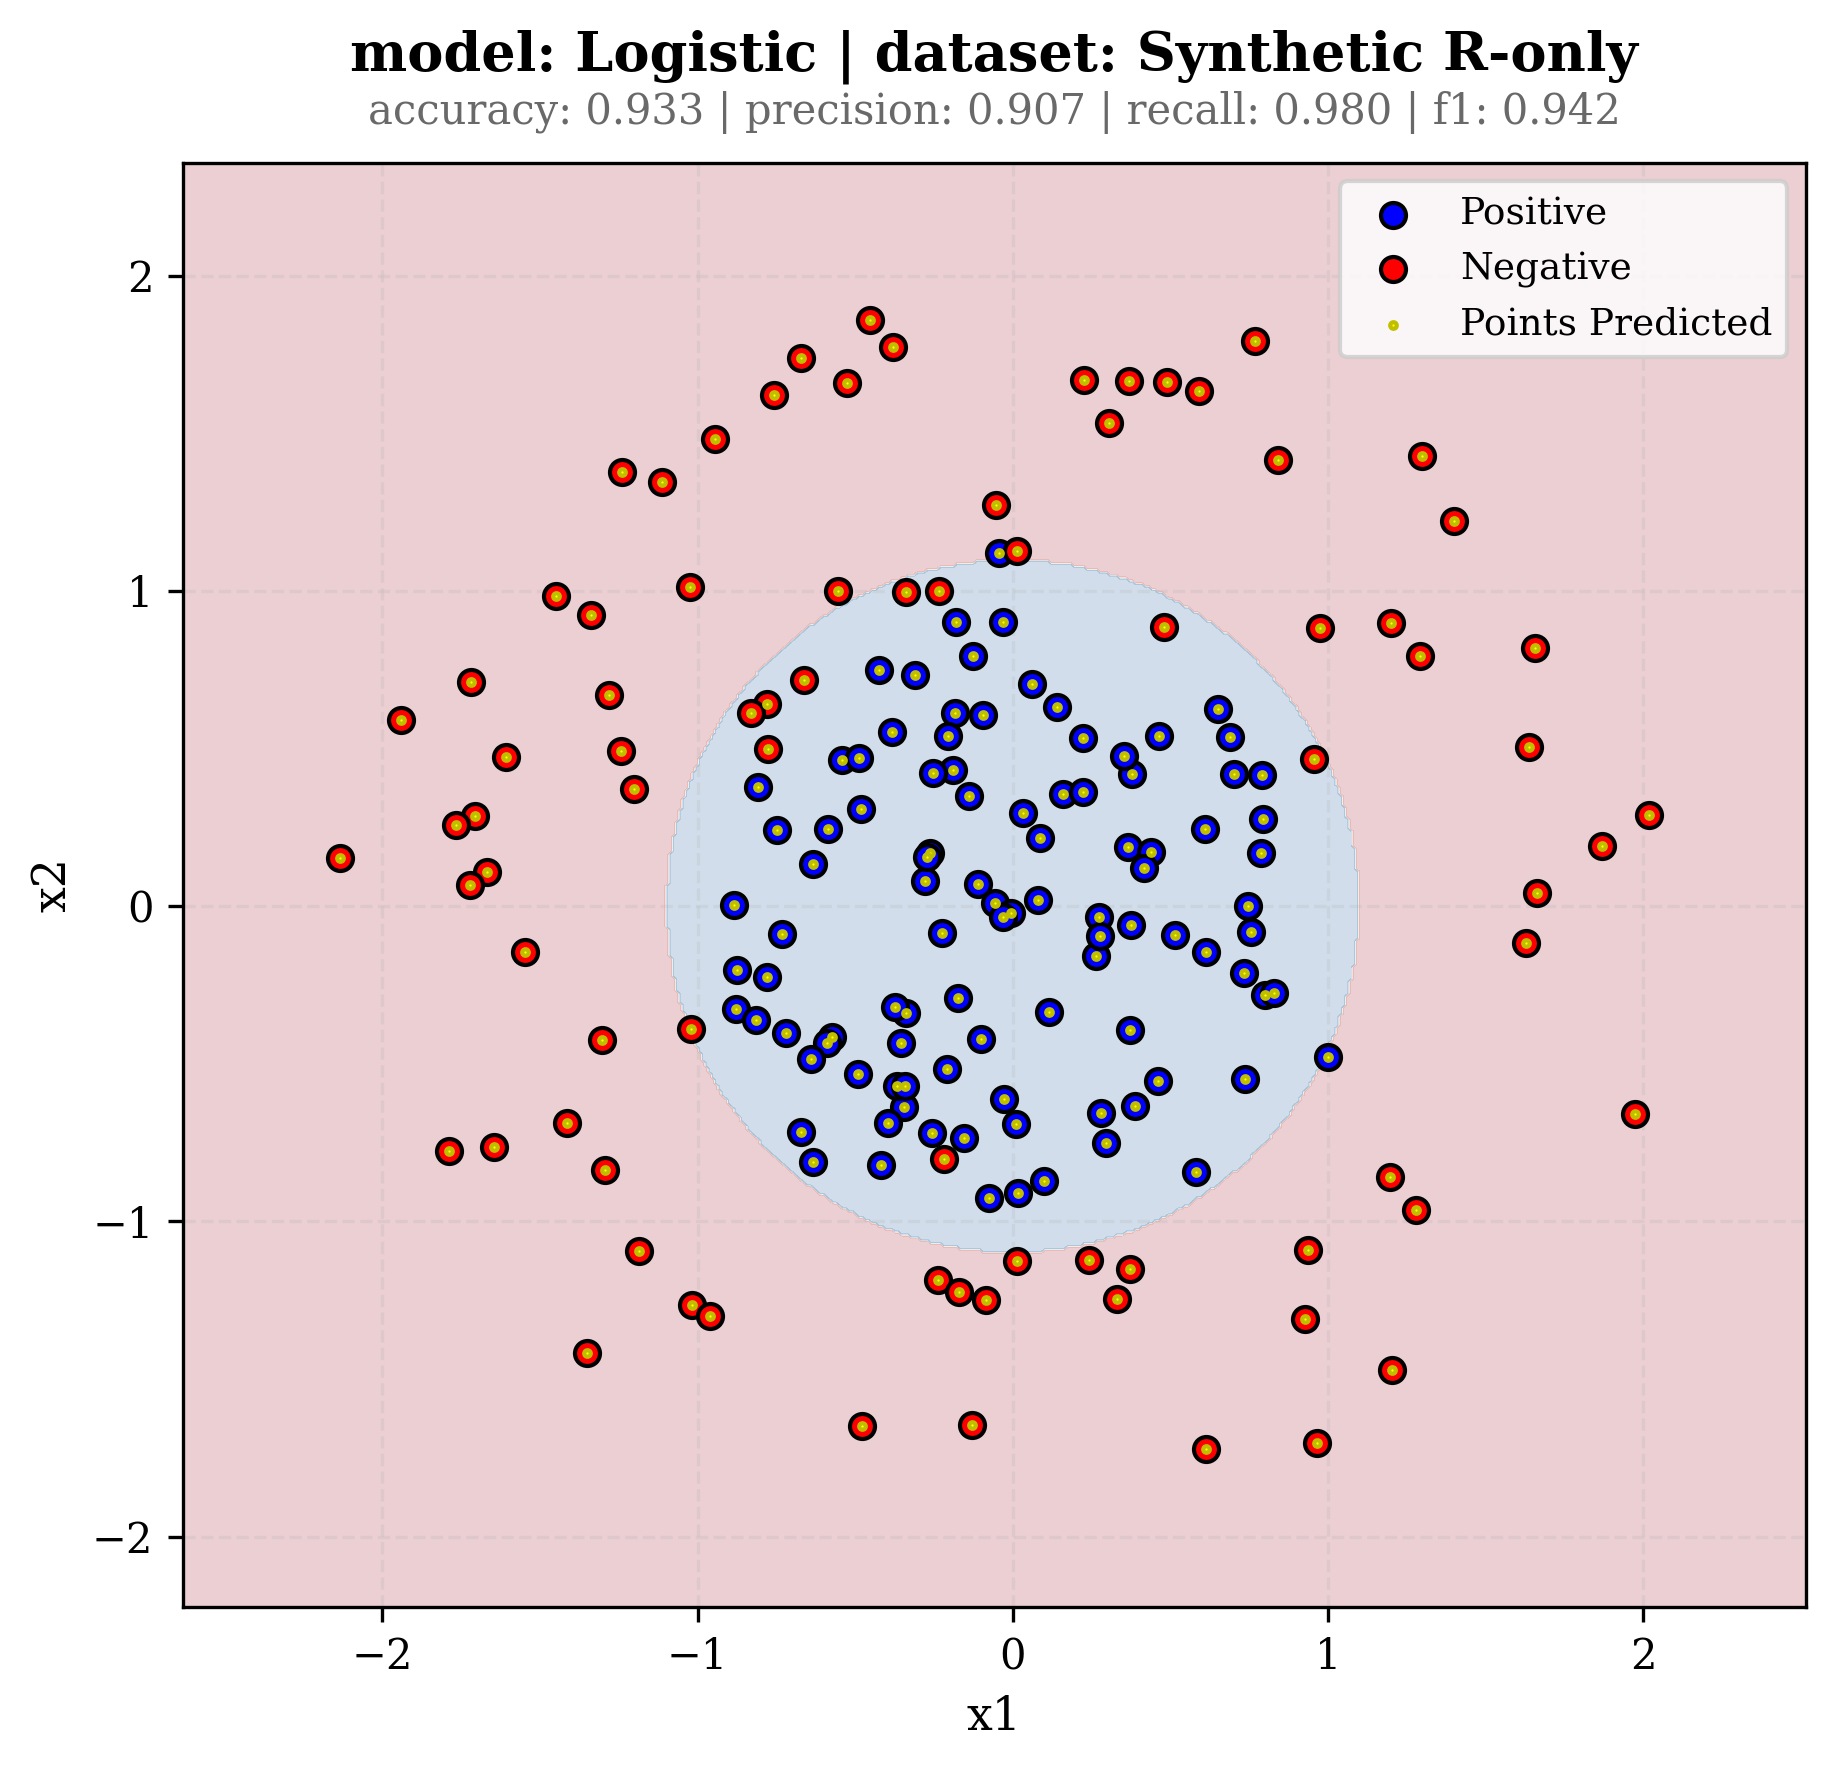

In [11]:
from sklearn.linear_model import LogisticRegression
from src.models.model_utilities import Model1DWrapper

lr_modelR = LogisticRegression(random_state=42)
lr_modelR.fit(X[['x1']], y)
lr_metricsR = ModelMetrics('Logistic Regression', 'R-only', y, lr_modelR.predict(X[['x1']]))
lr_metricsR.compute_metrics()
display(lr_metricsR.to_pandas())

wrapped_modelR = Model1DWrapper(trained_model=lr_modelR, vars_list=['x1'])

lr_R_fig, lr_R_ax = plot_decision_boundary(
    model=wrapped_modelR, dataset_X=X_cart, dataset_y=y,
    prediction_domain=grid_polar, grid_x=grid_x, grid_y=grid_y,
    title=f'model: Logistic | dataset: Synthetic R-only',
    metrics=lr_metricsR.to_dict()
)

lr_R_ax.set_aspect('equal')
display(lr_R_fig)

In [12]:
lr_metricsR.to_dict()

{'accuracy': 0.9333333333333333,
 'precision': 0.9074074074074074,
 'recall': 0.98,
 'f1': 0.9423076923076923}

,accuracy,precision,recall,f1
0,0.944444,0.916667,0.99,0.951923


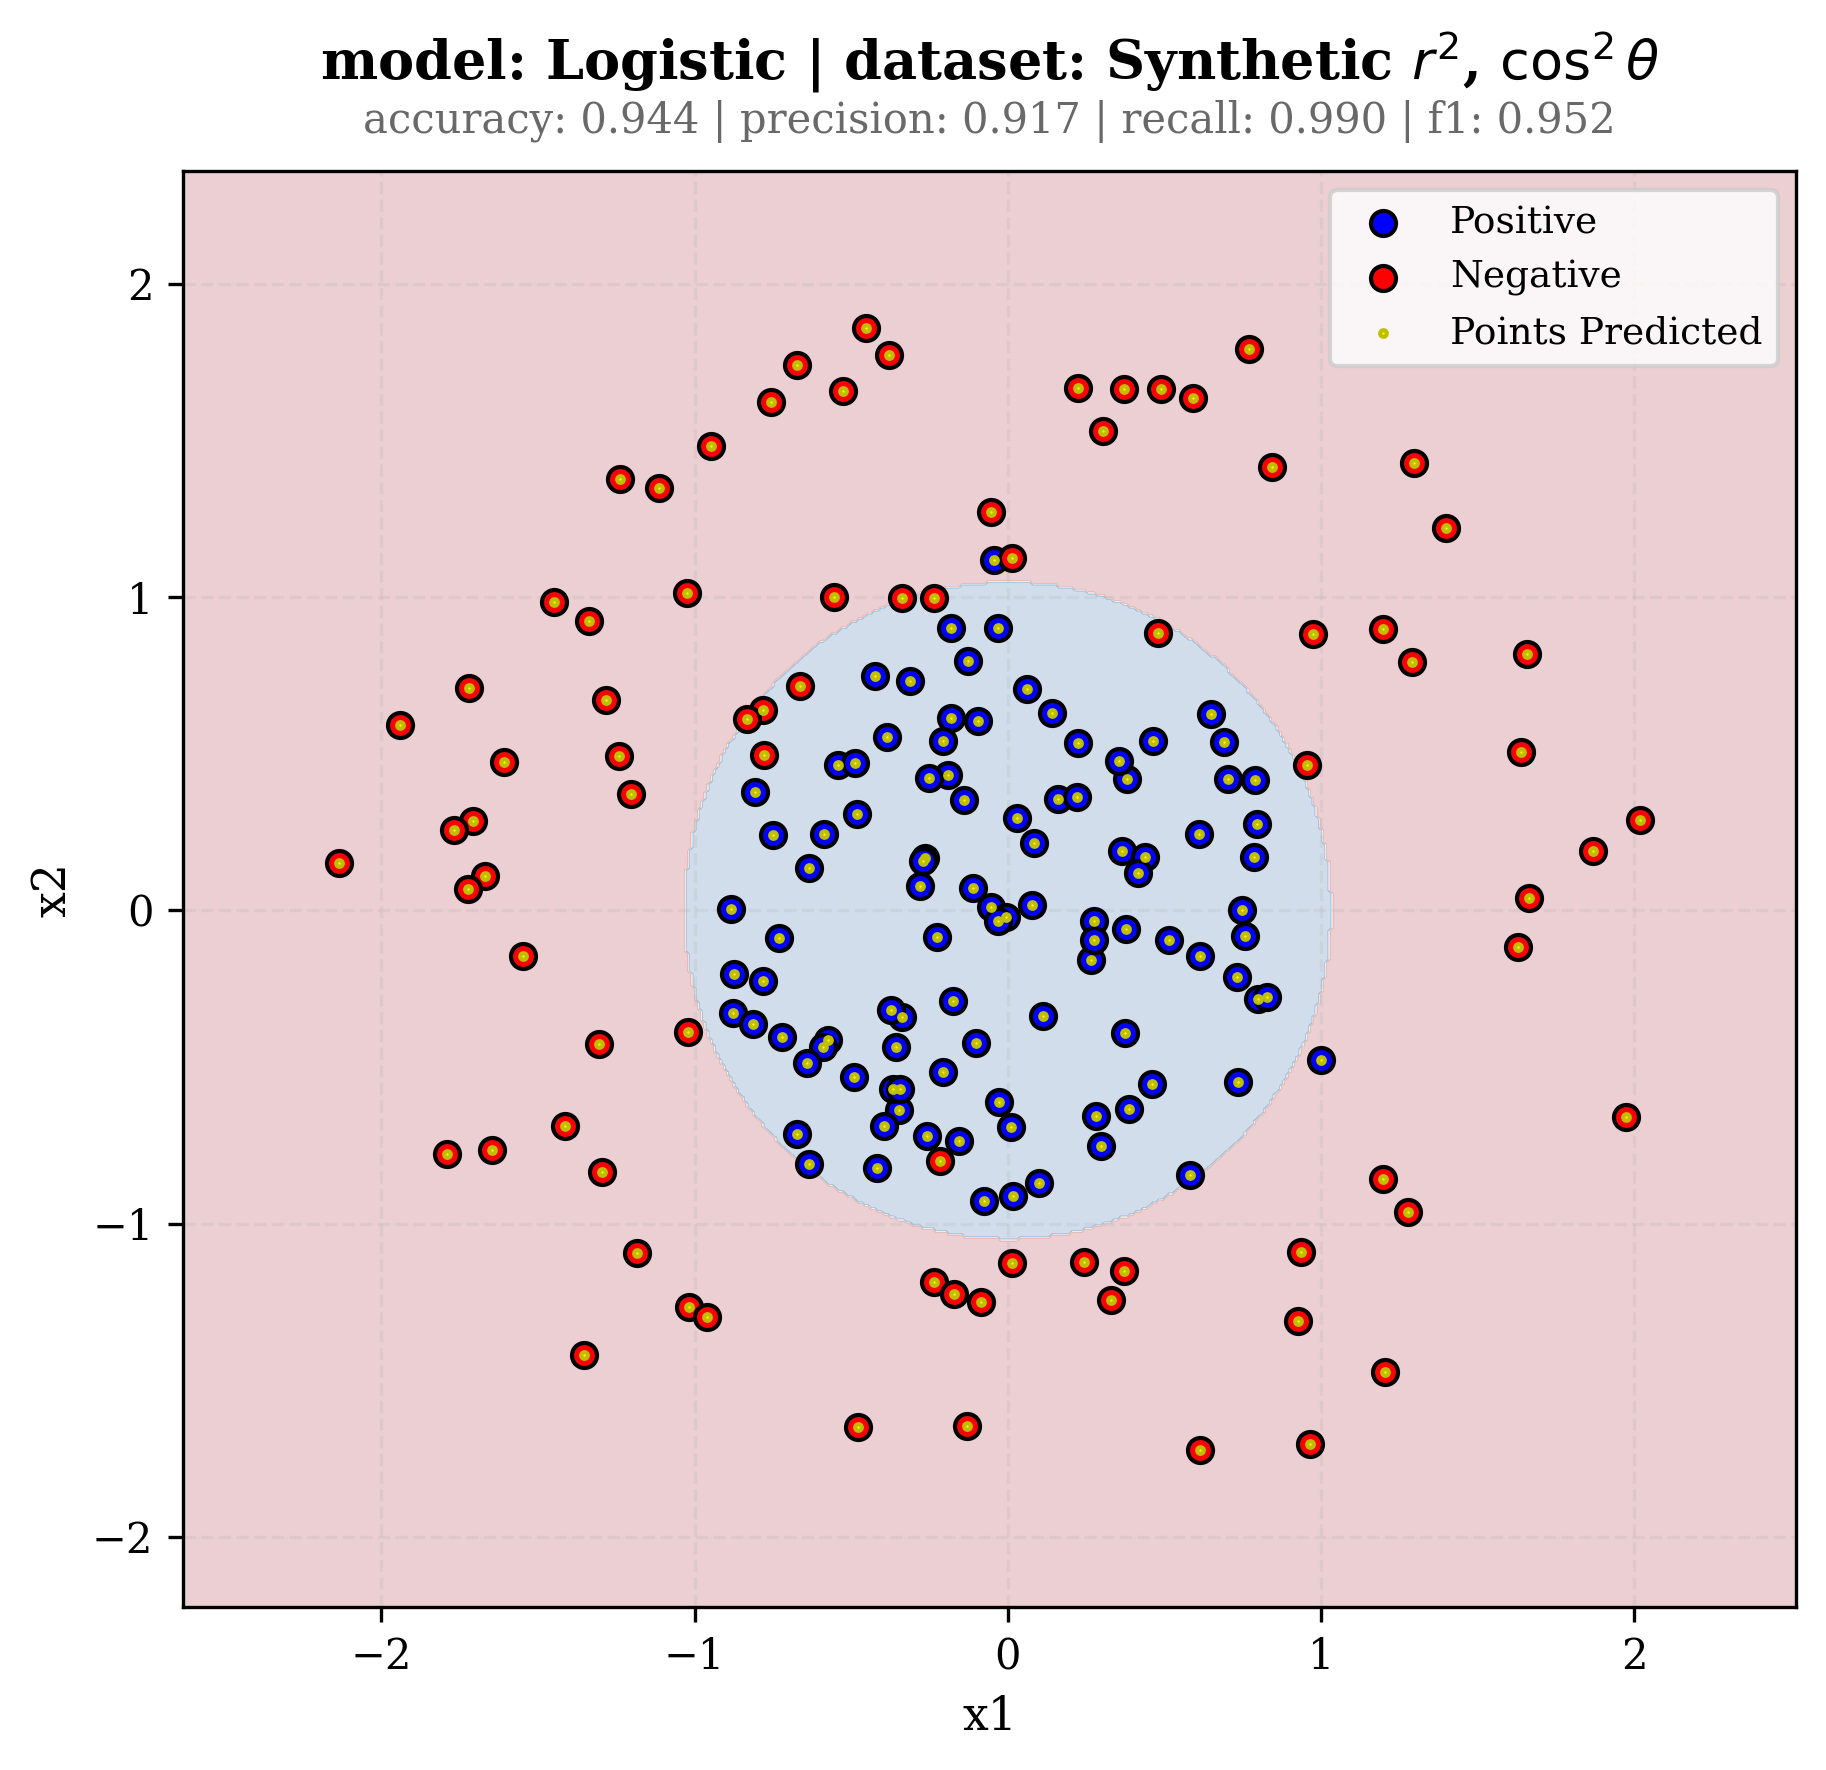

In [13]:
from src.visualization.decision_boundaries import plot_decision_boundary
from sklearn.linear_model import LogisticRegression
from src.evaluation.metrics import ModelMetrics

lr_model_cos2 = LogisticRegression(random_state=42)
lr_model_cos2.fit(X, y)
lr_metrics_cos2 = ModelMetrics('Logistic Regression', 'r^2,cos2()', y, lr_model_cos2.predict(X))
lr_metrics_cos2.compute_metrics()
display(lr_metrics_cos2.to_pandas())

dataset_label = r'$\cos^2{\theta}$'

lr_fig, lr_ax = plot_decision_boundary(
    model=lr_model_cos2, dataset_X=X_cart, dataset_y=y,
    prediction_domain=grid_cos_sqd, grid_x=grid_x, grid_y=grid_y,
    title=f'model: Logistic | dataset: Synthetic $r^2$, {dataset_label}',
    metrics=lr_metrics_cos2.to_dict()
)
lr_ax.set_aspect('equal')
display(lr_fig)

In [14]:
lr_metrics_cos2.to_dict()

{'accuracy': 0.9444444444444444,
 'precision': 0.9166666666666666,
 'recall': 0.99,
 'f1': 0.9519230769230769}

,accuracy,precision,recall,f1
0,0.966667,0.951923,0.99,0.970588


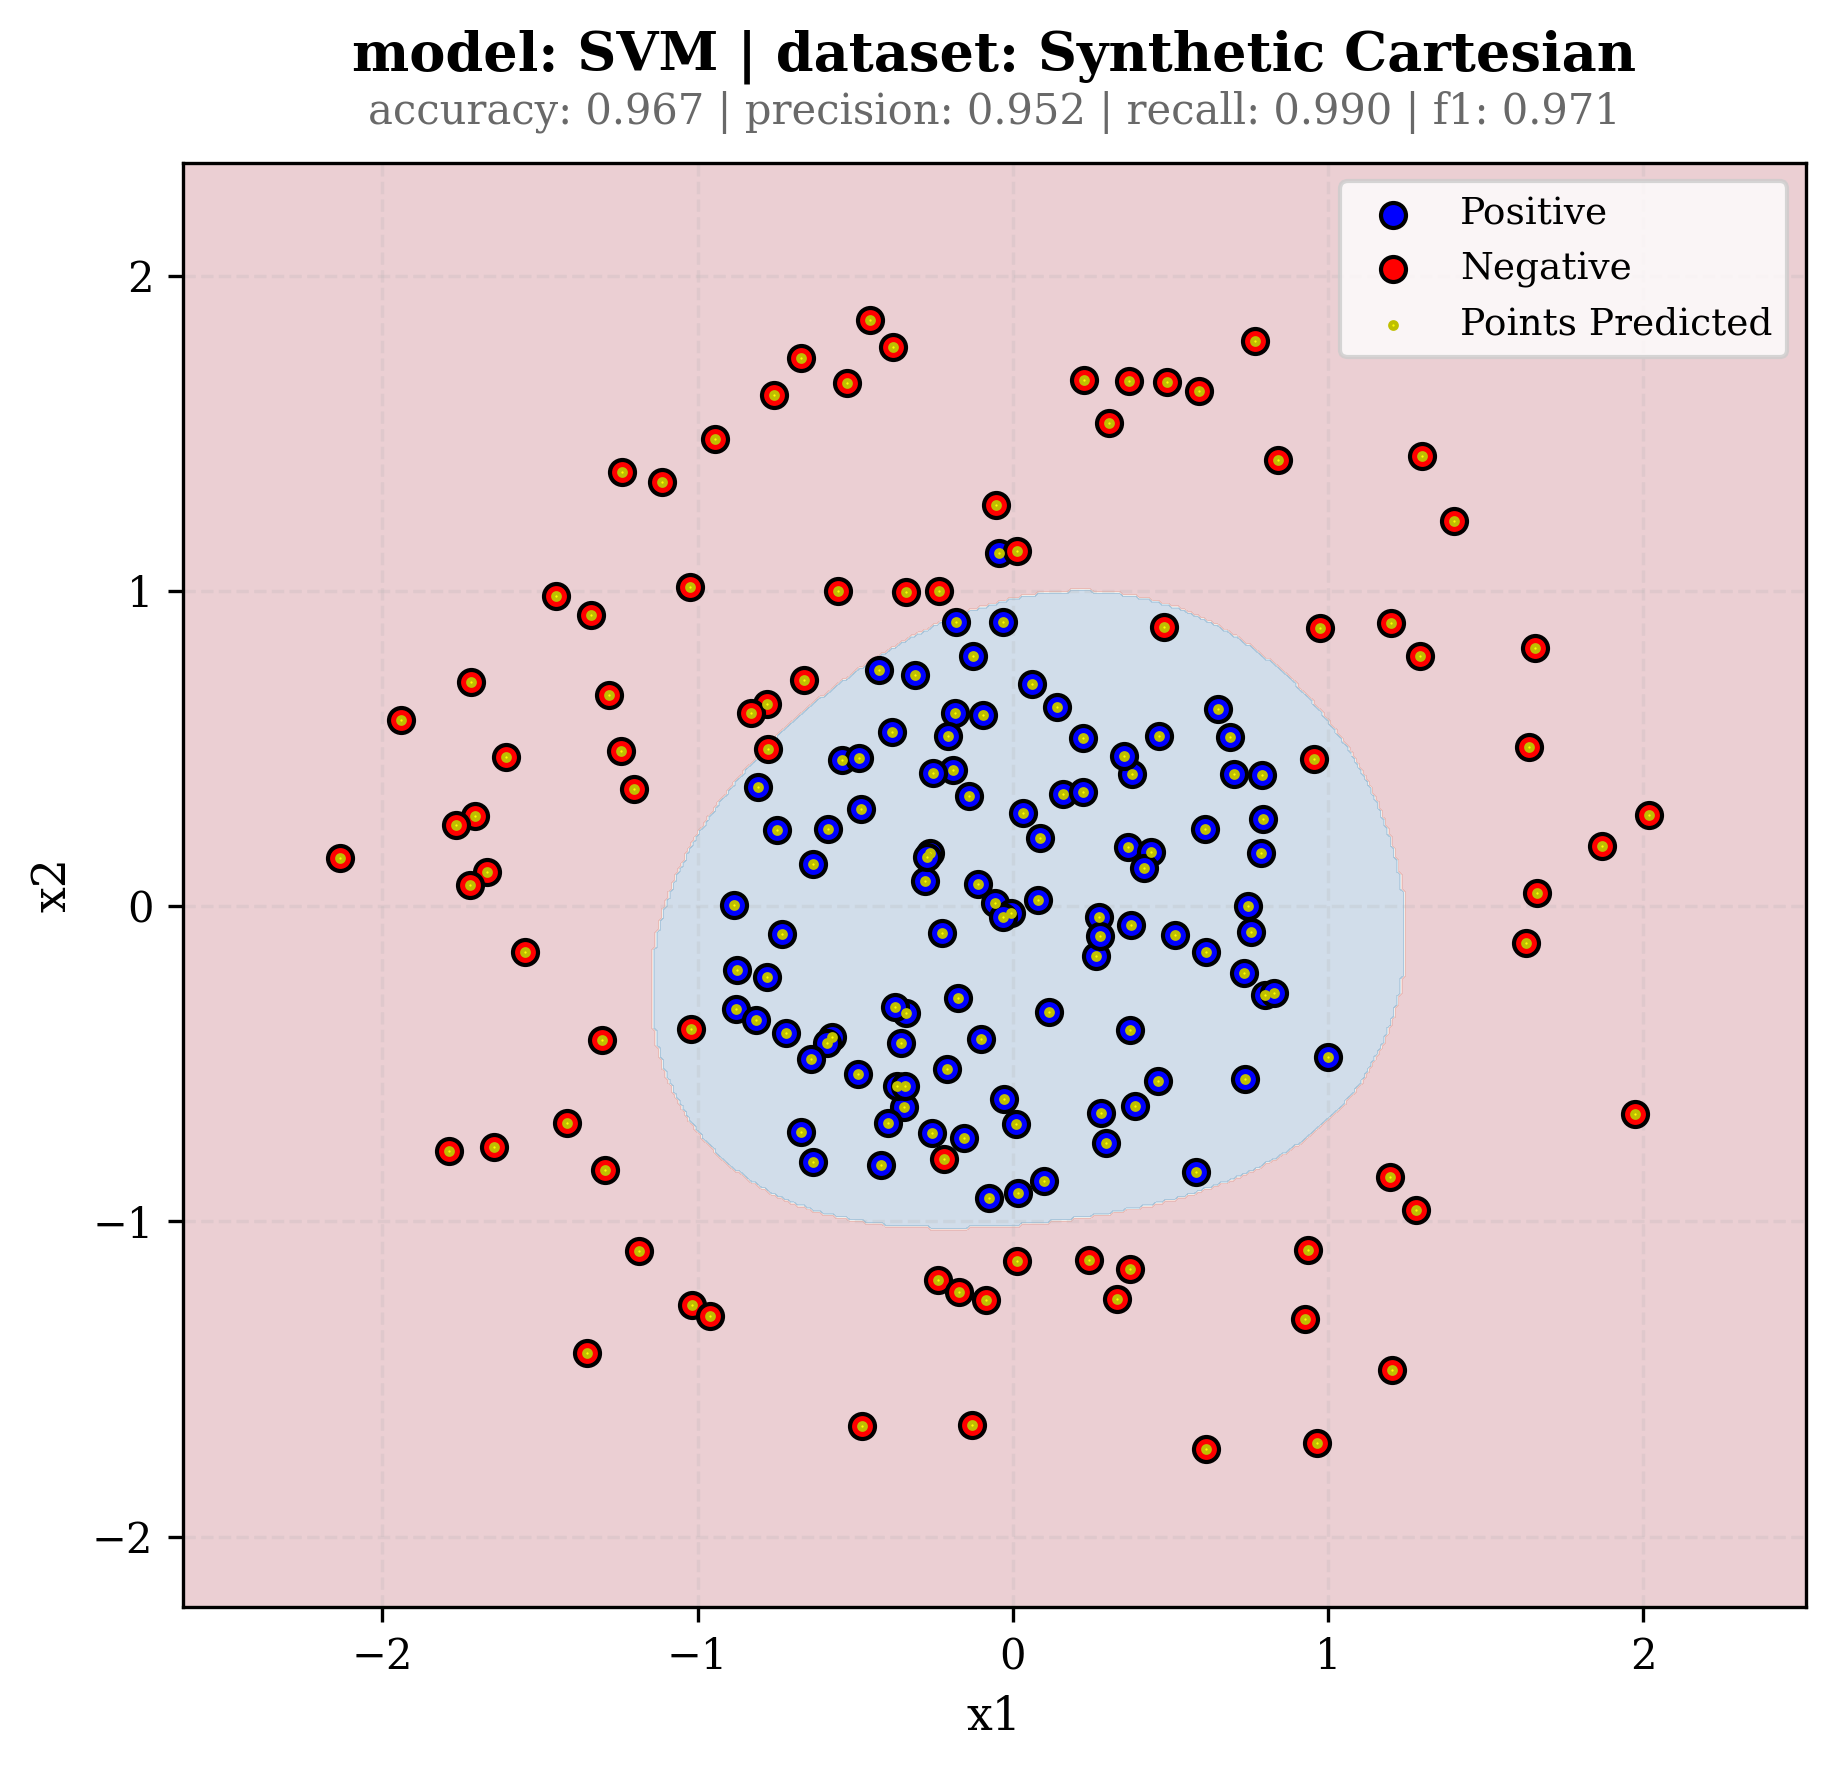

In [15]:
from src.visualization.decision_boundaries import plot_decision_boundary
from sklearn.svm import SVC

svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_cart, y)
svm_metrics = ModelMetrics('SVM', 'Cartesian', y, svm_model.predict(X_cart))
svm_metrics.compute_metrics()
display(svm_metrics.to_pandas())

fig, ax = plot_decision_boundary(
    model=svm_model, dataset_X=X_cart, dataset_y=y,
    prediction_domain=grid_cartesian, grid_x=grid_x, grid_y=grid_y,
    title=f'model: SVM | dataset: Synthetic Cartesian',
    metrics=svm_metrics.to_dict()
)
ax.set_aspect('equal')
display(fig)

In [16]:
svm_metrics.to_dict()

{'accuracy': 0.9666666666666667,
 'precision': 0.9519230769230769,
 'recall': 0.99,
 'f1': 0.9705882352941176}

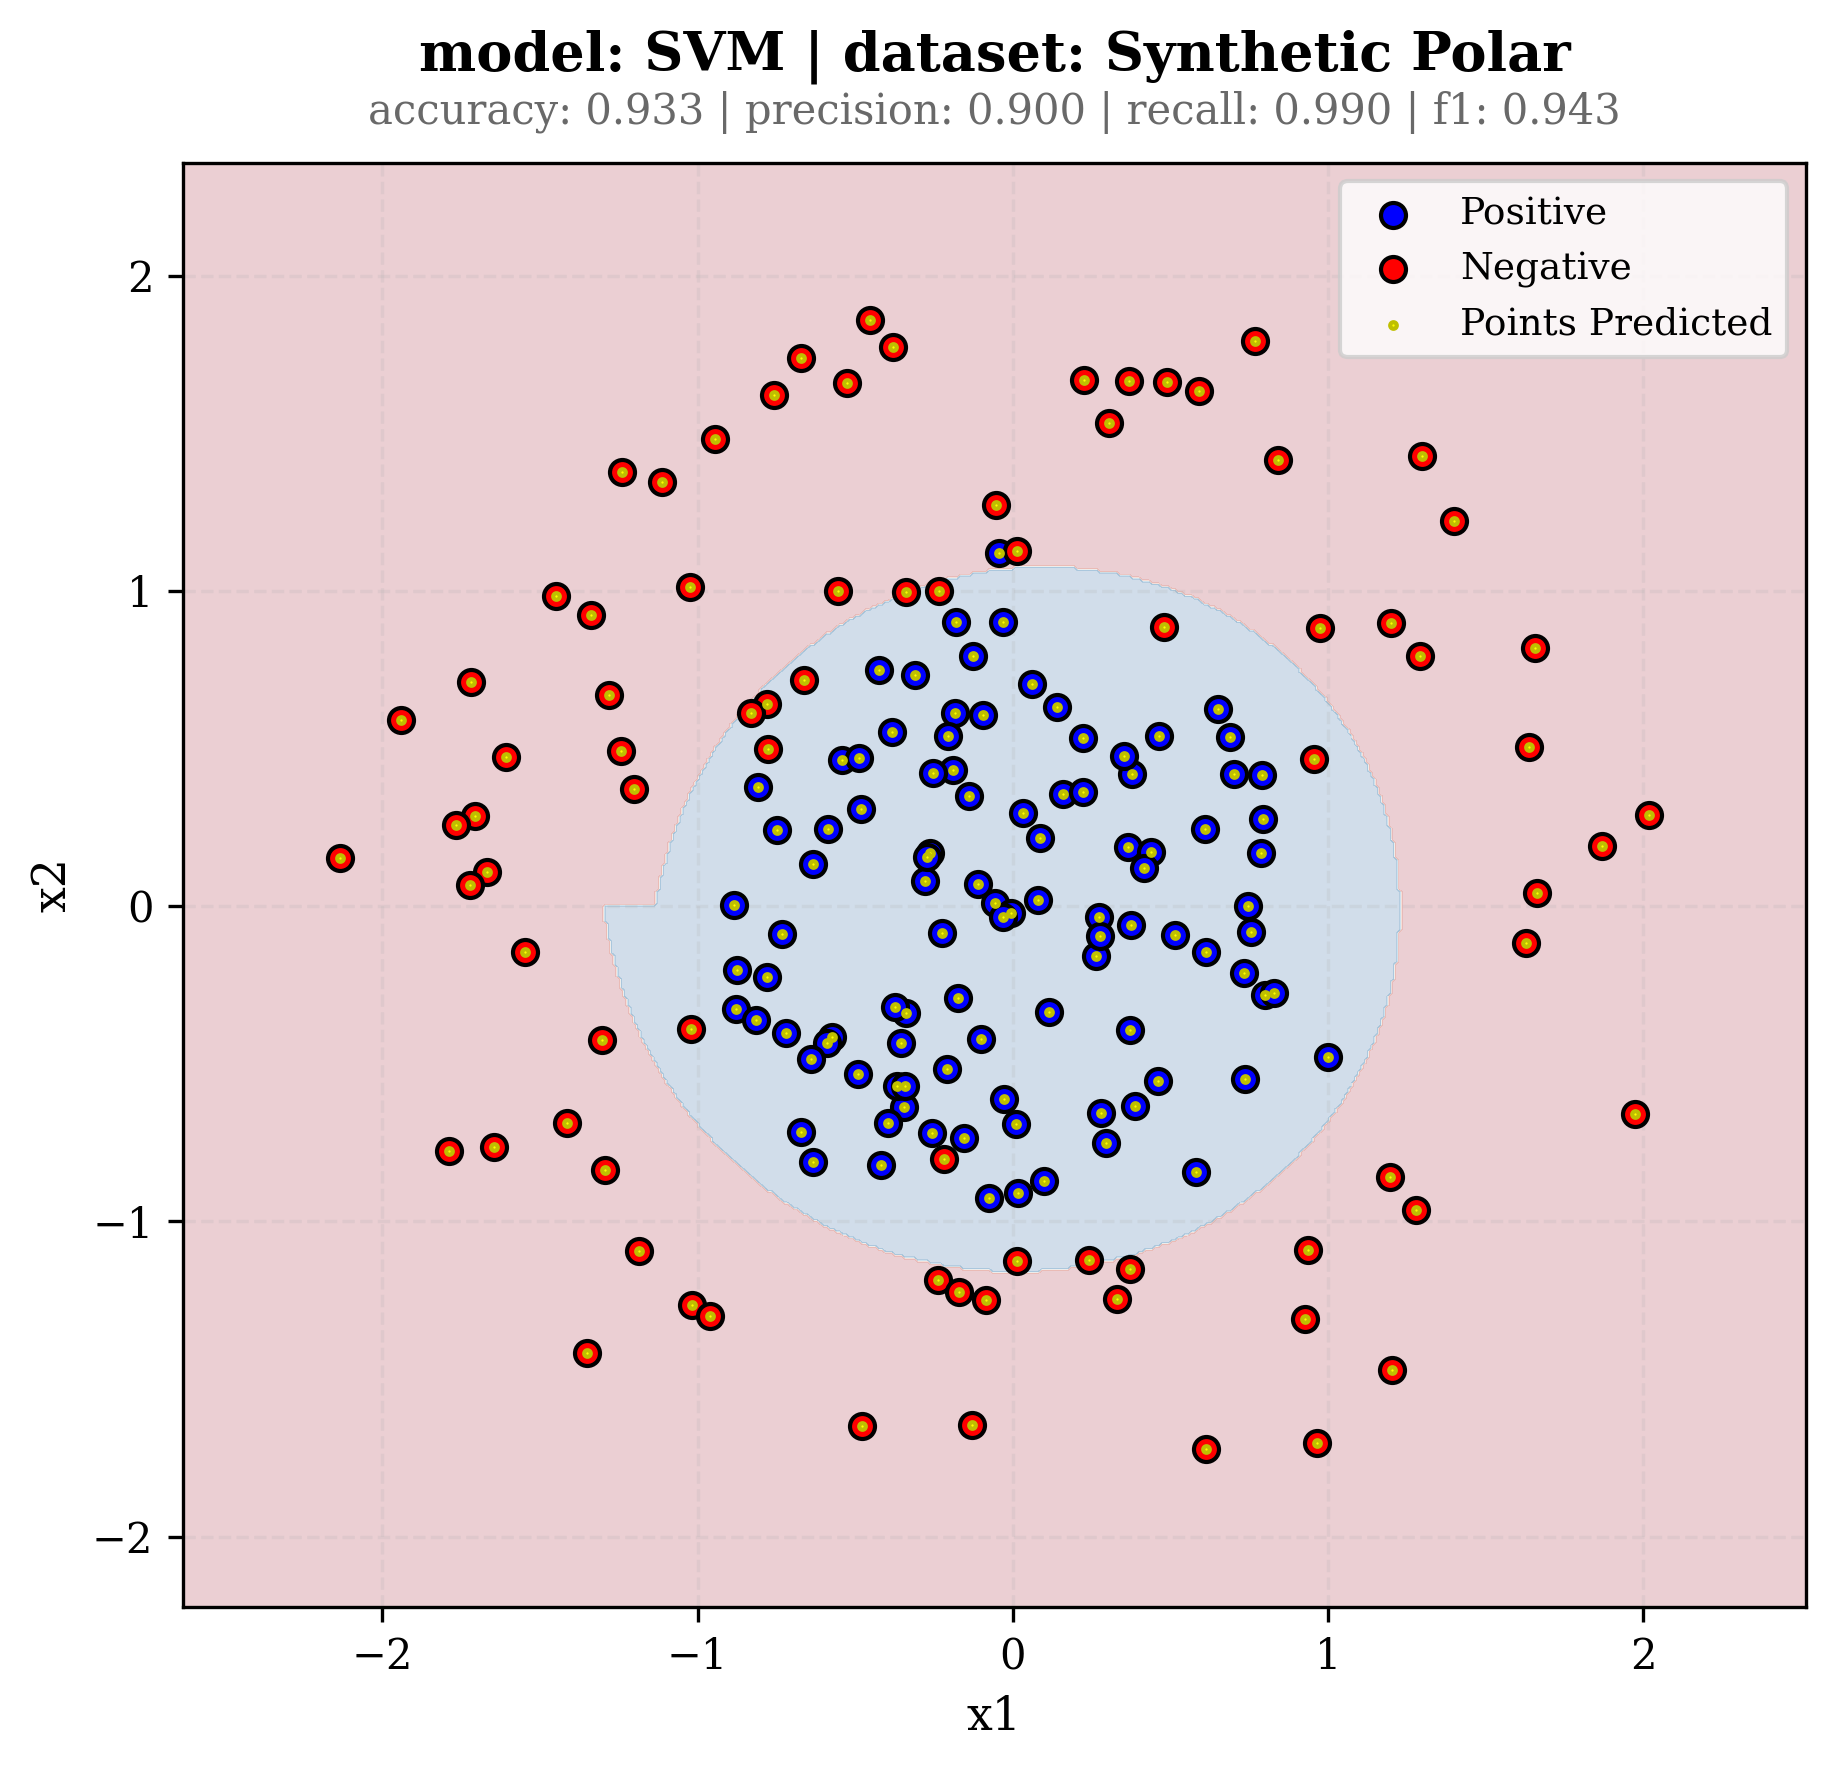

In [17]:
from src.visualization.decision_boundaries import plot_decision_boundary
from sklearn.svm import SVC

svm_polar_model = SVC(kernel='rbf', random_state=42)
svm_polar_model.fit(X, y)
svm_polar_metrics = ModelMetrics('SVM', 'Polar', y, svm_polar_model.predict(X))
svm_polar_metrics.compute_metrics()

fig, ax = plot_decision_boundary(
    model=svm_polar_model, dataset_X=X_cart, dataset_y=y,
    prediction_domain=grid_polar, grid_x=grid_x, grid_y=grid_y,
    title=f'model: SVM | dataset: Synthetic Polar',
    metrics=svm_polar_metrics.to_dict()
)
ax.set_aspect('equal')
display(fig)

In [18]:
svm_polar_metrics.to_dict()

{'accuracy': 0.9333333333333333,
 'precision': 0.9,
 'recall': 0.99,
 'f1': 0.9428571428571428}

## Noise Experiments

In [19]:
from sklearn.model_selection import cross_validate

### Small Datasets

In [20]:
num_points1 = 100
num_points2 = 100
r_min = 0.0
r_cutoff = 1.0
delta_r_cutoff = 0.0
r_max = 2 * 1.0
overall_noise = 0.1

X1 = pd.DataFrame(
    generate_uniform_ring_points(
        num_points=num_points1, 
        r_min=r_min, r_max=r_cutoff, 
        noise_std=overall_noise,
        coord_system='polar'
        ), columns=['x1', 'x2']
)

X2 = pd.DataFrame(
    generate_uniform_ring_points(
        num_points=num_points2, 
        r_min=r_cutoff+delta_r_cutoff, r_max=r_max,
        noise_std=overall_noise, 
        coord_system='polar'
        ), columns=['x1', 'x2']
)

X = pd.concat([X1, X2])
y = np.concat([np.ones(len(X1)), np.zeros(len(X2))])

X_cart = pd.DataFrame(
    {
        'x1': X['x1'] * np.cos(X['x2']),
        'x2': X['x1'] * np.sin(X['x2'])
    }
)
X_cos2 = polar_to_curvilinear_r2cos2theta(X['x1'], X['x2'])

In [21]:
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline

# Initialize with 5 folds
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

folds = list(skf.split(X_cart, y))

In [22]:
logreg_polar_pipeline = Pipeline([
    ("logreg_polar", LogisticRegression())
])
scoring = ["accuracy", "precision", "recall", "f1"]
logreg_polar_results = cross_validate(
    logreg_polar_pipeline,
    X,
    y,
    cv=folds,
    scoring=scoring,
    return_train_score=True
)

logreg_R_pipeline = Pipeline([
    ("logreg_R", LogisticRegression())
])
scoring = ["accuracy", "precision", "recall", "f1"]
logreg_R_results = cross_validate(
    logreg_R_pipeline,
    X[['x1']],
    y,
    cv=folds,
    scoring=scoring,
    return_train_score=True
)

logreg_cos2_pipeline = Pipeline([
    ("logreg_cos2", LogisticRegression())
])
scoring = ["accuracy", "precision", "recall", "f1"]
logreg__cos2_results = cross_validate(
    logreg_cos2_pipeline,
    X_cos2,
    y,
    cv=folds,
    scoring=scoring,
    return_train_score=True
)

svm_pipeline = Pipeline([
    ("svm", SVC(kernel="rbf"))
])
scoring = ["accuracy", "precision", "recall", "f1"]
svm_results = cross_validate(
    svm_pipeline,
    X_cart,
    y,
    cv=folds,
    scoring=scoring,
    return_train_score=True
)

svm_polar_pipeline = Pipeline([
    ("svm", SVC(kernel="rbf"))
])
scoring = ["accuracy", "precision", "recall", "f1"]
svm_polar_results = cross_validate(
    svm_polar_pipeline,
    X,
    y,
    cv=folds,
    scoring=scoring,
    return_train_score=True
)

In [23]:
models_test = {}
models_train = {}

for key in svm_results.keys():
    svm_metrics = svm_results[key]
    svm_polar_metrics = svm_polar_results[key]
    logreg_metrics = logreg_polar_results[key]
    logreg_R_metrics = logreg_R_results[key]
    logreg_cos2_metrics = logreg__cos2_results[key]

    if 'train' in key:
        models_train[key] = {}
        my_dict = models_train
    else:
        models_test[key] = {}
        my_dict = models_test

    my_dict[key] = [f'{np.mean(svm_metrics):.5f} +/- {np.std(svm_metrics):.5f}',
                    f'{np.mean(svm_polar_metrics):.5f} +/- {np.std(svm_polar_metrics):.5f}', 
                    f'{np.mean(logreg_metrics):.5f} +/- {np.std(logreg_metrics):.5f}', 
                    f'{np.mean(logreg_R_metrics):.5f} +/- {np.std(logreg_R_metrics):.5f}', 
                    f'{np.mean(logreg_cos2_metrics):.5f} +/- {np.std(logreg_cos2_metrics):.5f}']

model_names = ['SVM', 'SVM-polar', 'LogReg-Polar', 'LogReg-R-only', 'LogReg-r2cos2']

models_test_df = pd.DataFrame(models_test, index=model_names)
models_train_df = pd.DataFrame(models_train, index=model_names)

display(models_test_df)
display(models_train_df)

,fit_time,score_time,test_accuracy,test_precision,test_recall,test_f1
SVM,0.00059 +/- 0.00003,0.00187 +/- 0.00014,0.94500 +/- 0.02915,0.93325 +/- 0.03827,0.96000 +/- 0.03742,0.94584 +/- 0.02900
SVM-polar,0.00057 +/- 0.00001,0.00191 +/- 0.00006,0.96000 +/- 0.02550,0.93621 +/- 0.04404,0.99000 +/- 0.02000,0.96164 +/- 0.02398
LogReg-Polar,0.00210 +/- 0.00121,0.00360 +/- 0.00097,0.94500 +/- 0.02449,0.93455 +/- 0.04569,0.96000 +/- 0.02000,0.94630 +/- 0.02270
LogReg-R-only,0.00082 +/- 0.00007,0.00221 +/- 0.00019,0.95500 +/- 0.03317,0.94320 +/- 0.04412,0.97000 +/- 0.02449,0.95607 +/- 0.03168
LogReg-r2cos2,0.00075 +/- 0.00007,0.00179 +/- 0.00006,0.95500 +/- 0.03674,0.93463 +/- 0.04655,0.98000 +/- 0.02449,0.95656 +/- 0.03516


,train_accuracy,train_precision,train_recall,train_f1
SVM,0.96250 +/- 0.00884,0.94501 +/- 0.01532,0.98250 +/- 0.01275,0.96326 +/- 0.00854
SVM-polar,0.96250 +/- 0.01118,0.93878 +/- 0.01961,0.99000 +/- 0.00500,0.96360 +/- 0.01063
LogReg-Polar,0.95250 +/- 0.00500,0.93937 +/- 0.00717,0.96750 +/- 0.00612,0.95321 +/- 0.00488
LogReg-R-only,0.95875 +/- 0.00848,0.94225 +/- 0.01143,0.97750 +/- 0.00500,0.95954 +/- 0.00820
LogReg-r2cos2,0.95625 +/- 0.00791,0.93560 +/- 0.00932,0.98000 +/- 0.00612,0.95728 +/- 0.00765


### Medium-Sized Datasets

In [24]:
num_points1 = 500
num_points2 = 500
r_min = 0.0
r_cutoff = 1.0
delta_r_cutoff = 0.0
r_max = 2 * 1.0
overall_noise = 0.1

X1 = pd.DataFrame(
    generate_uniform_ring_points(
        num_points=num_points1, 
        r_min=r_min, r_max=r_cutoff, 
        noise_std=overall_noise,
        coord_system='polar'
        ), columns=['x1', 'x2']
)

X2 = pd.DataFrame(
    generate_uniform_ring_points(
        num_points=num_points2, 
        r_min=r_cutoff+delta_r_cutoff, r_max=r_max,
        noise_std=overall_noise, 
        coord_system='polar'
        ), columns=['x1', 'x2']
)

X = pd.concat([X1, X2])
y = np.concat([np.ones(len(X1)), np.zeros(len(X2))])

X_cart = pd.DataFrame(
    {
        'x1': X['x1'] * np.cos(X['x2']),
        'x2': X['x1'] * np.sin(X['x2'])
    }
)
X_cos2 = polar_to_curvilinear_r2cos2theta(X['x1'], X['x2'])

In [25]:
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline

# Initialize with 5 folds
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

folds = list(skf.split(X_cart, y))

In [26]:
logreg_polar_pipeline = Pipeline([
    ("logreg_polar", LogisticRegression())
])
scoring = ["accuracy", "precision", "recall", "f1"]
logreg_polar_results = cross_validate(
    logreg_polar_pipeline,
    X,
    y,
    cv=folds,
    scoring=scoring,
    return_train_score=True
)

logreg_R_pipeline = Pipeline([
    ("logreg_R", LogisticRegression())
])
scoring = ["accuracy", "precision", "recall", "f1"]
logreg_R_results = cross_validate(
    logreg_R_pipeline,
    X[['x1']],
    y,
    cv=folds,
    scoring=scoring,
    return_train_score=True
)

logreg_cos2_pipeline = Pipeline([
    ("logreg_cos2", LogisticRegression())
])
scoring = ["accuracy", "precision", "recall", "f1"]
logreg__cos2_results = cross_validate(
    logreg_cos2_pipeline,
    X_cos2,
    y,
    cv=folds,
    scoring=scoring,
    return_train_score=True
)

svm_pipeline = Pipeline([
    ("svm", SVC(kernel="rbf"))
])
scoring = ["accuracy", "precision", "recall", "f1"]
svm_results = cross_validate(
    svm_pipeline,
    X_cart,
    y,
    cv=folds,
    scoring=scoring,
    return_train_score=True
)

svm_polar_pipeline = Pipeline([
    ("svm", SVC(kernel="rbf"))
])
scoring = ["accuracy", "precision", "recall", "f1"]
svm_polar_results = cross_validate(
    svm_polar_pipeline,
    X,
    y,
    cv=folds,
    scoring=scoring,
    return_train_score=True
)

In [27]:
models_test = {}
models_train = {}

for key in svm_results.keys():
    svm_metrics = svm_results[key]
    svm_polar_metrics = svm_polar_results[key]
    logreg_metrics = logreg_polar_results[key]
    logreg_R_metrics = logreg_R_results[key]
    logreg_cos2_metrics = logreg__cos2_results[key]

    if 'train' in key:
        models_train[key] = {}
        my_dict = models_train
    else:
        models_test[key] = {}
        my_dict = models_test

    my_dict[key] = [f'{np.mean(svm_metrics):.5f} +/- {np.std(svm_metrics):.5f}',
                    f'{np.mean(svm_polar_metrics):.5f} +/- {np.std(svm_polar_metrics):.5f}', 
                    f'{np.mean(logreg_metrics):.5f} +/- {np.std(logreg_metrics):.5f}', 
                    f'{np.mean(logreg_R_metrics):.5f} +/- {np.std(logreg_R_metrics):.5f}', 
                    f'{np.mean(logreg_cos2_metrics):.5f} +/- {np.std(logreg_cos2_metrics):.5f}']

model_names = ['SVM', 'SVM-polar', 'LogReg-Polar', 'LogReg-R-only', 'LogReg-r2cos2']

models_test_df = pd.DataFrame(models_test, index=model_names)
models_train_df = pd.DataFrame(models_train, index=model_names)

display(models_test_df)
display(models_train_df)

,fit_time,score_time,test_accuracy,test_precision,test_recall,test_f1
SVM,0.00181 +/- 0.00006,0.00262 +/- 0.00008,0.94300 +/- 0.01470,0.91610 +/- 0.02276,0.97600 +/- 0.01200,0.94494 +/- 0.01380
SVM-polar,0.00199 +/- 0.00007,0.00276 +/- 0.00006,0.94300 +/- 0.01435,0.91131 +/- 0.02000,0.98200 +/- 0.01166,0.94523 +/- 0.01343
LogReg-Polar,0.00252 +/- 0.00176,0.00339 +/- 0.00082,0.94600 +/- 0.01772,0.92110 +/- 0.02153,0.97600 +/- 0.02059,0.94760 +/- 0.01725
LogReg-R-only,0.00096 +/- 0.00007,0.00215 +/- 0.00012,0.94000 +/- 0.01483,0.91390 +/- 0.02016,0.97200 +/- 0.01470,0.94193 +/- 0.01417
LogReg-r2cos2,0.00092 +/- 0.00004,0.00186 +/- 0.00007,0.94100 +/- 0.01625,0.91401 +/- 0.02031,0.97400 +/- 0.01625,0.94294 +/- 0.01559


,train_accuracy,train_precision,train_recall,train_f1
SVM,0.94425 +/- 0.00423,0.91577 +/- 0.00265,0.97850 +/- 0.00682,0.94609 +/- 0.00421
SVM-polar,0.94225 +/- 0.00255,0.90856 +/- 0.00380,0.98350 +/- 0.00406,0.94454 +/- 0.00243
LogReg-Polar,0.94400 +/- 0.00443,0.91888 +/- 0.00507,0.97400 +/- 0.00406,0.94563 +/- 0.00425
LogReg-R-only,0.94025 +/- 0.00391,0.91359 +/- 0.00509,0.97250 +/- 0.00316,0.94212 +/- 0.00370
LogReg-r2cos2,0.94075 +/- 0.00341,0.91523 +/- 0.00460,0.97150 +/- 0.00300,0.94252 +/- 0.00323


### Large Dataset

In [28]:
num_points1 = 4000
num_points2 = 4000
r_min = 0.0
r_cutoff = 1.0
delta_r_cutoff = 0.0
r_max = 2 * 1.0
overall_noise = 0.1

X1 = pd.DataFrame(
    generate_uniform_ring_points(
        num_points=num_points1, 
        r_min=r_min, r_max=r_cutoff, 
        noise_std=overall_noise,
        coord_system='polar'
        ), columns=['x1', 'x2']
)

X2 = pd.DataFrame(
    generate_uniform_ring_points(
        num_points=num_points2, 
        r_min=r_cutoff+delta_r_cutoff, r_max=r_max,
        noise_std=overall_noise, 
        coord_system='polar'
        ), columns=['x1', 'x2']
)

X = pd.concat([X1, X2])
y = np.concat([np.ones(len(X1)), np.zeros(len(X2))])

X_cart = pd.DataFrame(
    {
        'x1': X['x1'] * np.cos(X['x2']),
        'x2': X['x1'] * np.sin(X['x2'])
    }
)
X_cos2 = polar_to_curvilinear_r2cos2theta(X['x1'], X['x2'])

In [29]:
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline

# Initialize with 5 folds
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

folds = list(skf.split(X_cart, y))

In [30]:
logreg_polar_pipeline = Pipeline([
    ("logreg_polar", LogisticRegression())
])
scoring = ["accuracy", "precision", "recall", "f1"]
logreg_polar_results = cross_validate(
    logreg_polar_pipeline,
    X,
    y,
    cv=folds,
    scoring=scoring,
    return_train_score=True
)

logreg_R_pipeline = Pipeline([
    ("logreg_R", LogisticRegression())
])
scoring = ["accuracy", "precision", "recall", "f1"]
logreg_R_results = cross_validate(
    logreg_R_pipeline,
    X[['x1']],
    y,
    cv=folds,
    scoring=scoring,
    return_train_score=True
)

logreg_cos2_pipeline = Pipeline([
    ("logreg_cos2", LogisticRegression())
])
scoring = ["accuracy", "precision", "recall", "f1"]
logreg__cos2_results = cross_validate(
    logreg_cos2_pipeline,
    X_cos2,
    y,
    cv=folds,
    scoring=scoring,
    return_train_score=True
)

svm_pipeline = Pipeline([
    ("svm", SVC(kernel="rbf"))
])
scoring = ["accuracy", "precision", "recall", "f1"]
svm_results = cross_validate(
    svm_pipeline,
    X_cart,
    y,
    cv=folds,
    scoring=scoring,
    return_train_score=True
)

svm_polar_pipeline = Pipeline([
    ("svm", SVC(kernel="rbf"))
])
scoring = ["accuracy", "precision", "recall", "f1"]
svm_polar_results = cross_validate(
    svm_polar_pipeline,
    X,
    y,
    cv=folds,
    scoring=scoring,
    return_train_score=True
)

In [31]:
models_test = {}
models_train = {}

for key in svm_results.keys():
    svm_metrics = svm_results[key]
    svm_polar_metrics = svm_polar_results[key]
    logreg_metrics = logreg_polar_results[key]
    logreg_R_metrics = logreg_R_results[key]
    logreg_cos2_metrics = logreg__cos2_results[key]

    if 'train' in key:
        models_train[key] = {}
        my_dict = models_train
    else:
        models_test[key] = {}
        my_dict = models_test

    my_dict[key] = [f'{np.mean(svm_metrics):.5f} +/- {np.std(svm_metrics):.5f}',
                    f'{np.mean(svm_polar_metrics):.5f} +/- {np.std(svm_polar_metrics):.5f}', 
                    f'{np.mean(logreg_metrics):.5f} +/- {np.std(logreg_metrics):.5f}', 
                    f'{np.mean(logreg_R_metrics):.5f} +/- {np.std(logreg_R_metrics):.5f}', 
                    f'{np.mean(logreg_cos2_metrics):.5f} +/- {np.std(logreg_cos2_metrics):.5f}']

model_names = ['SVM', 'SVM-polar', 'LogReg-Polar', 'LogReg-R-only', 'LogReg-r2cos2']

models_test_df = pd.DataFrame(models_test, index=model_names)
models_train_df = pd.DataFrame(models_train, index=model_names)

display(models_test_df)
display(models_train_df)

,fit_time,score_time,test_accuracy,test_precision,test_recall,test_f1
SVM,0.04884 +/- 0.00241,0.03112 +/- 0.00105,0.95538 +/- 0.00528,0.94596 +/- 0.00791,0.96600 +/- 0.00464,0.95586 +/- 0.00512
SVM-polar,0.05488 +/- 0.00117,0.03691 +/- 0.00117,0.95437 +/- 0.00385,0.94042 +/- 0.00583,0.97025 +/- 0.00267,0.95510 +/- 0.00369
LogReg-Polar,0.00402 +/- 0.00188,0.00348 +/- 0.00112,0.95500 +/- 0.00285,0.94698 +/- 0.00437,0.96400 +/- 0.00521,0.95540 +/- 0.00284
LogReg-R-only,0.00174 +/- 0.00010,0.00215 +/- 0.00012,0.95488 +/- 0.00260,0.94675 +/- 0.00434,0.96400 +/- 0.00539,0.95528 +/- 0.00261
LogReg-r2cos2,0.00207 +/- 0.00010,0.00208 +/- 0.00011,0.95488 +/- 0.00283,0.94566 +/- 0.00467,0.96525 +/- 0.00550,0.95534 +/- 0.00282


,train_accuracy,train_precision,train_recall,train_f1
SVM,0.95619 +/- 0.00074,0.94752 +/- 0.00149,0.96588 +/- 0.00085,0.95661 +/- 0.00071
SVM-polar,0.95453 +/- 0.00068,0.94100 +/- 0.00123,0.96988 +/- 0.00164,0.95522 +/- 0.00069
LogReg-Polar,0.95494 +/- 0.00070,0.94673 +/- 0.00113,0.96413 +/- 0.00100,0.95535 +/- 0.00069
LogReg-R-only,0.95494 +/- 0.00074,0.94662 +/- 0.00119,0.96425 +/- 0.00111,0.95535 +/- 0.00073
LogReg-r2cos2,0.95522 +/- 0.00098,0.94654 +/- 0.00166,0.96494 +/- 0.00075,0.95565 +/- 0.00094


# Wrapping Uniform Ring Data Generation

In [32]:
num_points1 = 50
num_points2 = 50
r_min = 0.0
r_cutoff = 1.0
delta_r_cutoff = 0.0
r_max = 2 * 1.0
overall_noise = 0.1
noise_std = (overall_noise, overall_noise)

XX, yy = generate_uniform_ring_synthetic_dataset(
    num_points1=num_points1, num_points2=num_points2,r_min=r_min,r_bound=r_cutoff,delta_r=delta_r_cutoff,r_max=r_max,coord_system='polar',noise_std=noise_std
)

XX_cart = pd.DataFrame(
    {
        'x1': XX['x1'] * np.cos(XX['x2']),
        'x2': XX['x1'] * np.sin(XX['x2'])
    }
)

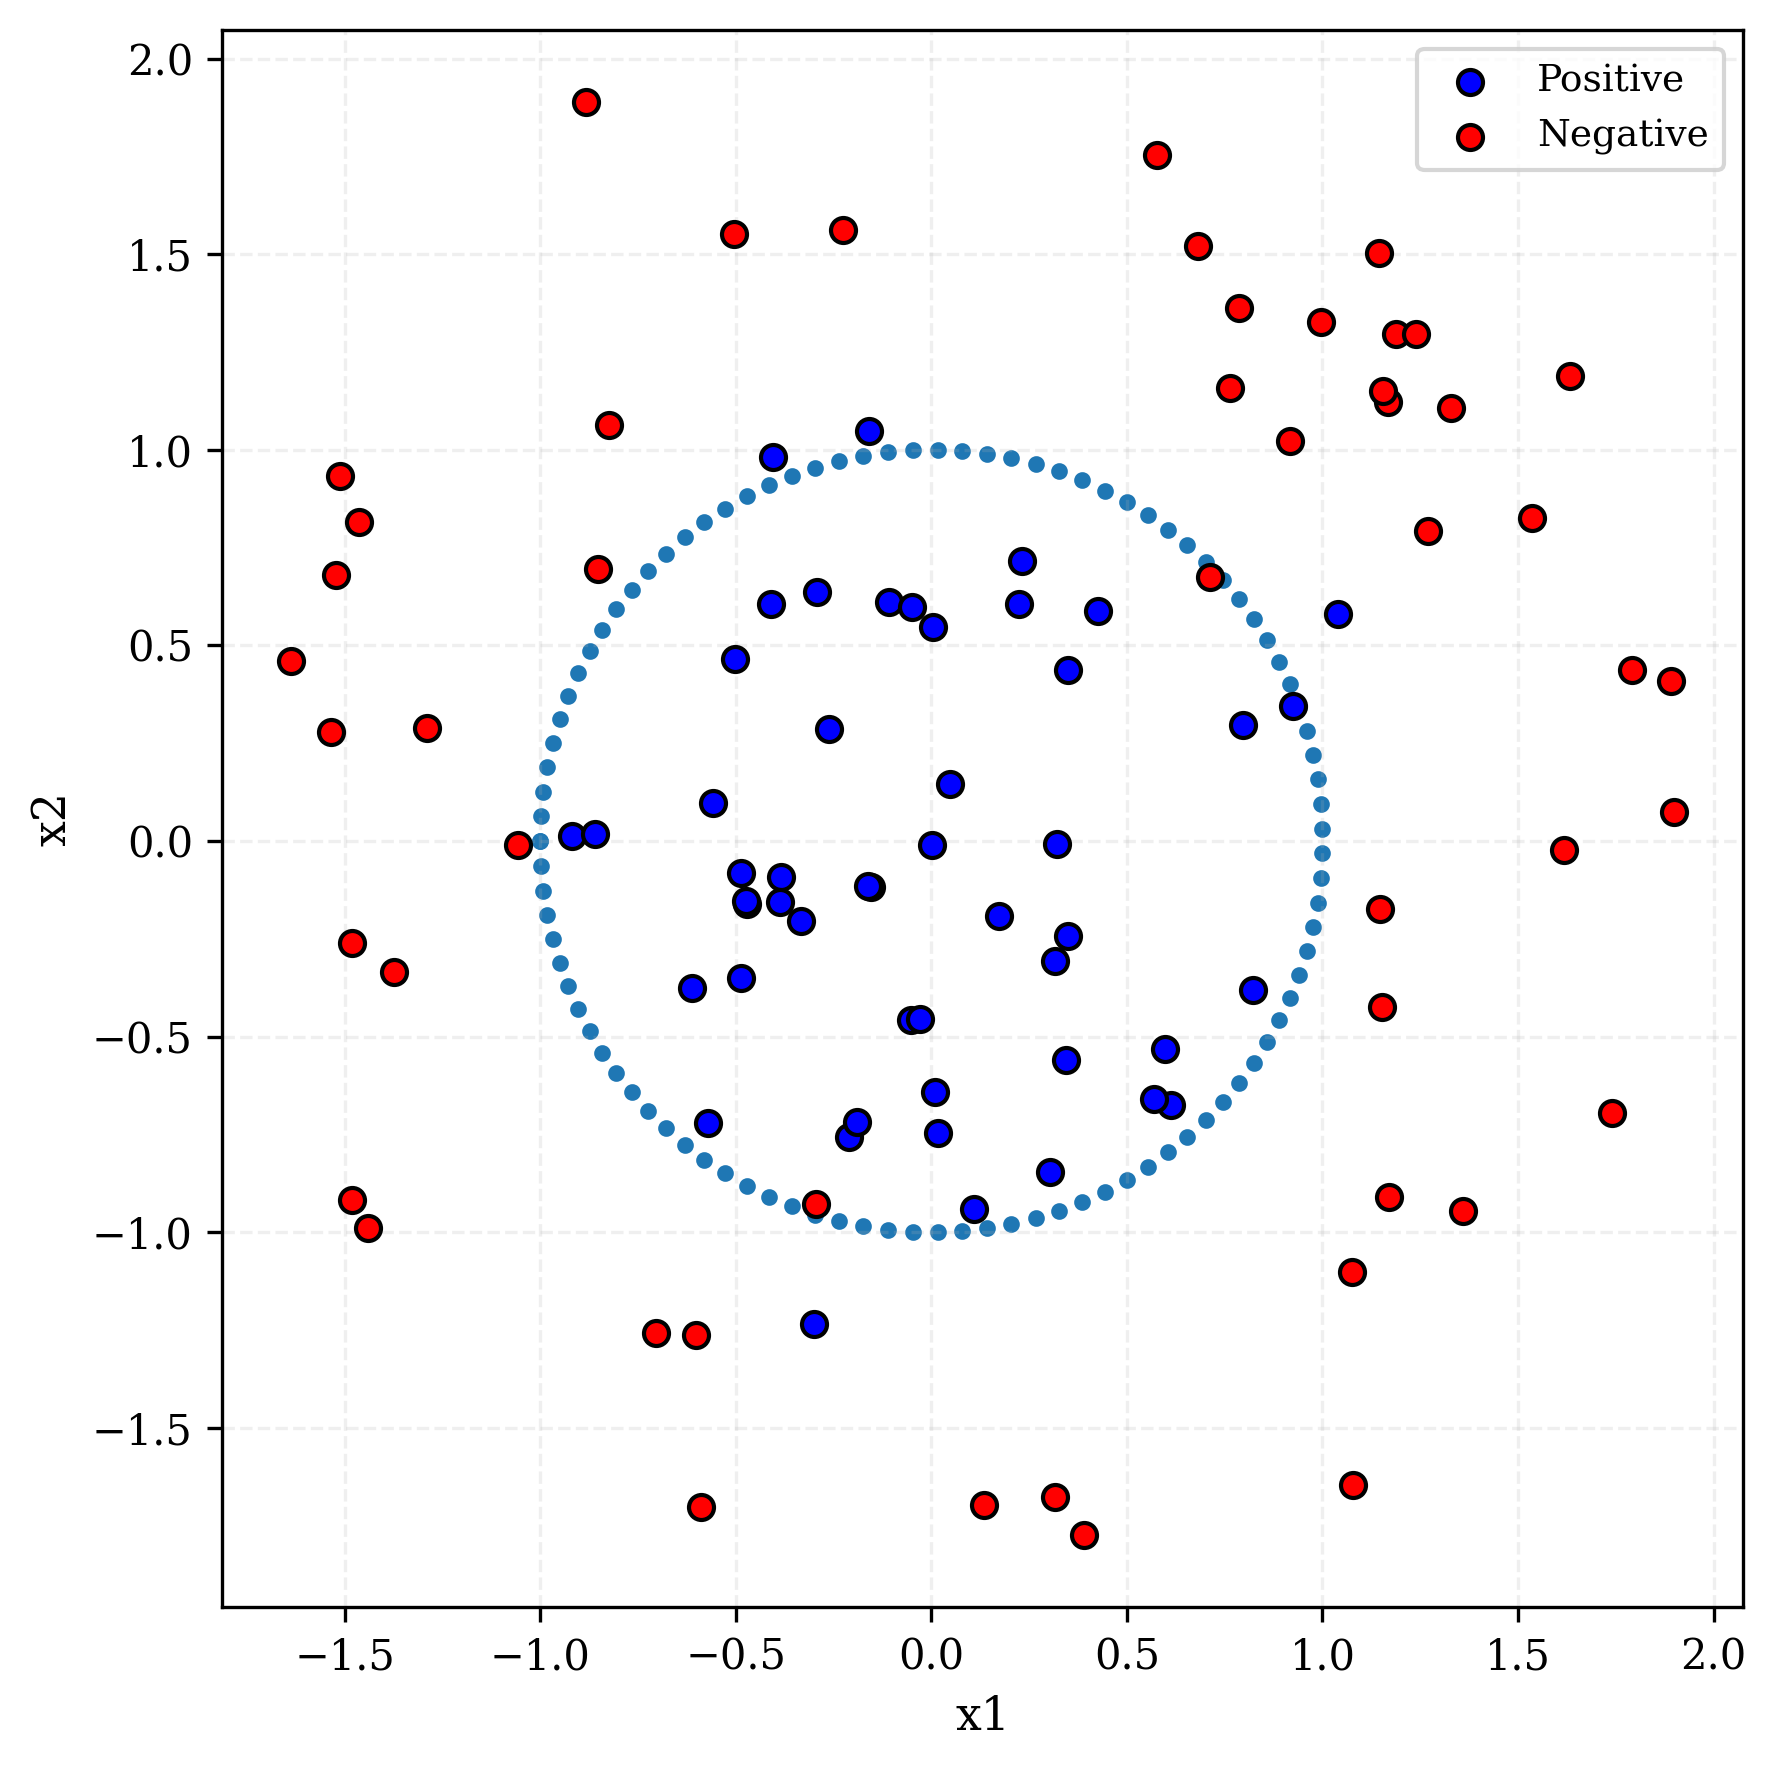

In [33]:
raw_data_fig, raw_data_ax = plot_in_rectangular_coordinates(X=XX_cart, y=yy, title='', axis_x='x1', axis_y='x2')
R = r_cutoff
Thetas = np.linspace(-np.pi, np.pi, 100)
raw_data_ax.scatter(R*np.cos(Thetas), R*np.sin(Thetas), marker='.')
raw_data_ax.set_aspect('equal')
display(raw_data_fig)